## Clean Data Guard

This notebook reads cleaned parquet tables from `clean/`. Run `clean_data.ipynb` first if those files are missing.


In [ ]:
from pathlib import Path
if not Path("clean/results.parquet").exists():
    raise FileNotFoundError("clean/results.parquet not found. Run clean_data.ipynb first to create the cleaned parquet tables in clean/.")


# Data Engineering Questions

This notebook starts from the cleaned parquet tables in `clean/`. It does not re-clean raw data and treats `tables` as read-only.


In [ ]:
from pathlib import Path
import re, hashlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import spearmanr, kendalltau
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from IPython.display import display
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 140)

de_clean_dir = Path("clean")
de_fig_dir = Path("figures_de")
de_fig_dir.mkdir(exist_ok=True)
de_table_names = ["circuits","constructors","constructor_results","constructor_standings","drivers","driver_standings","races","results","qualifying","lap_times","pit_stops","sprint_results","seasons","status","nationality_country"]
tables = {de_name: pd.read_parquet(de_clean_dir / f"{de_name}.parquet") for de_name in de_table_names}
de_results_check = tables["results"]
print("results rows:", len(de_results_check))
de_results_duplicate_keys = int(de_results_check[["raceId","driverId"]].duplicated().sum())
assert de_results_duplicate_keys == 0, f"results has {de_results_duplicate_keys} duplicate (raceId, driverId) keys"

def de_table_hash(de_table):
    de_obj = de_table.copy(deep=True).reindex(sorted(de_table.columns), axis=1)
    return hashlib.sha256(pd.util.hash_pandas_object(de_obj, index=True).values.tobytes()).hexdigest()
de_table_hash_snapshot = {de_name: de_table_hash(de_table) for de_name, de_table in tables.items()}
print("Loaded tables:", len(tables))
print("Hash snapshot stored")


results rows: 24566
Loaded tables: 15
Hash snapshot stored


## Shared helpers

All analysis starts from `tables["results"].copy()`. Every join prints shapes and asserts unchanged row count. Wilson intervals are used for proportions.

In [ ]:
de_pre_hybrid_end_year = 2013
de_hybrid_start_year = 2014
de_q3_old_end_year = 2021
de_q3_new_start_year = 2022
de_q3_new_end_year = 2024
de_matched_pre_start_year = 2006
de_matched_pre_end_year = 2013
de_matched_post_start_year = 2014
de_matched_post_end_year = 2024
de_min_n = 10
de_min_n_q1_headline = 25
de_min_n_headline = 100
de_quali_coverage_threshold = 0.90
de_merge_lineages = True

def de_checked_merge(de_left, de_right, **de_kwargs):
    de_name = de_kwargs.pop("name", "join")
    de_before = de_left.shape
    de_out = de_left.merge(de_right, **de_kwargs)
    print(f"{de_name}: before={de_before}, after={de_out.shape}")
    assert len(de_out) == de_before[0], f"{de_name} changed row count"
    return de_out

def de_add_wilson(de_df, de_success_col, de_total_col, de_prefix):
    de_out = de_df.copy()
    de_success = de_out[de_success_col].to_numpy(float)
    de_total = de_out[de_total_col].to_numpy(float)
    de_low = np.full(len(de_out), np.nan)
    de_high = np.full(len(de_out), np.nan)
    de_mask = de_total > 0
    de_low[de_mask], de_high[de_mask] = proportion_confint(de_success[de_mask], de_total[de_mask], method="wilson")
    de_out[f"{de_prefix}_ci_low"] = de_low
    de_out[f"{de_prefix}_ci_high"] = de_high
    return de_out

def de_era_pre_2014(de_year):
    return np.where(de_year <= de_pre_hybrid_end_year, "pre-2014", "2014+")

def de_era_q3(de_year):
    return np.select([(de_year >= 2014) & (de_year <= 2021), (de_year >= 2022) & (de_year <= 2024)], ["2014-2021", "2022-2024"], default=None)

def de_rank_conversion(de_df, de_front_col, de_era_col, de_min_starts=de_min_n):
    de_out = (de_df.loc[de_df[de_front_col]].groupby([de_era_col,"circuitId","circuit_name","circuit_country"], dropna=False).agg(starts=("podium","size"), podiums=("podium","sum")).reset_index())
    de_out["conversion"] = de_out["podiums"] / de_out["starts"]
    de_out = de_add_wilson(de_out, "podiums", "starts", "conversion")
    de_out = de_out.loc[de_out["starts"] >= de_min_starts].copy()
    de_out["rank"] = de_out.groupby(de_era_col)["conversion"].rank(ascending=False, method="min")
    return de_out.sort_values([de_era_col,"rank","starts"], ascending=[True,True,False])

def de_save_show(de_fig, de_name):
    de_path = de_fig_dir / de_name
    de_fig.savefig(de_path, dpi=160, bbox_inches="tight")
    print("Saved figure:", de_path.as_posix())
    plt.show()

def de_grouped_bar_ci(de_df, de_x, de_y, de_lo, de_hi, de_hue, de_order, de_hue_order, de_title, de_ylabel, de_rotation=45, de_figsize=(12,6)):
    de_fig, de_ax = plt.subplots(figsize=de_figsize)
    de_ax.grid(axis="x", visible=False)
    de_xpos = np.arange(len(de_order))
    de_width = 0.8 / len(de_hue_order)
    de_palette = sns.color_palette(n_colors=len(de_hue_order))
    for de_i, de_hue_value in enumerate(de_hue_order):
        de_sub = de_df.loc[de_df[de_hue].eq(de_hue_value)].set_index(de_x).reindex(de_order)
        de_offsets = de_xpos - 0.4 + de_width / 2 + de_i * de_width
        de_height = pd.to_numeric(de_sub[de_y], errors="coerce")
        de_low = pd.to_numeric(de_sub[de_lo], errors="coerce")
        de_high = pd.to_numeric(de_sub[de_hi], errors="coerce")
        de_valid = de_height.notna()
        de_ax.bar(de_offsets[de_valid], de_height.loc[de_valid], width=de_width, label=str(de_hue_value), color=de_palette[de_i])
        de_ax.errorbar(de_offsets[de_valid], de_height.loc[de_valid], yerr=[de_height.loc[de_valid]-de_low.loc[de_valid], de_high.loc[de_valid]-de_height.loc[de_valid]], fmt="none", color="black", capsize=3)
    de_ax.set_xticks(de_xpos)
    de_ax.set_xticklabels(de_order, rotation=de_rotation, ha="right" if de_rotation else "center")
    de_ax.set_title(de_title); de_ax.set_ylabel(de_ylabel); de_ax.set_xlabel(""); de_ax.legend(title=de_hue)
    de_fig.tight_layout()
    return de_fig, de_ax


# Q1. Front-row conversion by circuit

Grain is one cleaned result row per driver-race start. Grid and qualifying position are distinguished because grid reflects penalties and pit-lane starts.

Q1 results -> races: before=(24566, 6), after=(24566, 11)
Q1 -> circuits: before=(24566, 11), after=(24566, 13)
Q1 -> qualifying: before=(24566, 13), after=(24566, 14)
Q1 grid=0 pit-lane starts: 87 (never in the front row, so not counted)
Q1 grid != qualifying rows, including grid=0: 2482
Q1 grid != qualifying share among qualifying rows, including grid=0: 0.2384
Q1 grid != qualifying rows, excluding grid=0: 2410
Q1 grid != qualifying share among qualifying rows, excluding grid=0: 0.2331
Q1 >=90% qualifying coverage ranges: 1994-1995 and 2003-2024; gap 1996-2002
Q1 pre-2014 same-rows means the covered seasons only.


,year,rows,qualifying_rows,coverage
0,1950,119,0,0.0
1,1951,138,0,0.0
2,1952,165,0,0.0
3,1953,193,0,0.0
4,1954,160,0,0.0
...,...,...,...,...
70,2020,337,337,1.0
71,2021,437,436,0.997712
72,2022,439,439,1.0
73,2023,436,436,1.0


Saved figure: figures_de/q1_qualifying_coverage.png


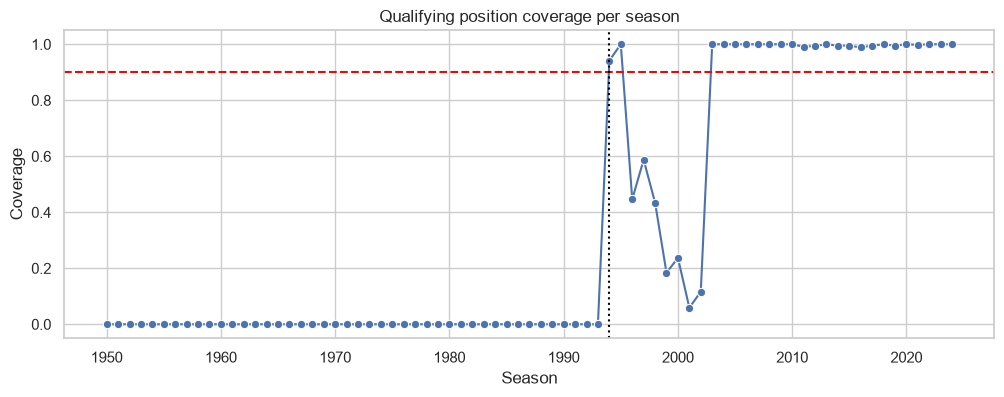

Q1 full-history grid conversion sensitivity table (n>=10; small samples included): (64, 10)


,era_pre_2014,circuitId,circuit_name,circuit_country,starts,podiums,conversion,conversion_ci_low,conversion_ci_high,rank
5,2014+,6,Circuit de Monaco,Monaco,19,17,0.894737,0.686059,0.970641,1.0
17,2014+,22,Suzuka Circuit,Japan,18,16,0.888889,0.672002,0.968980,2.0
18,2014+,24,Yas Marina Circuit,UAE,22,19,0.863636,0.666650,0.952510,3.0
3,2014+,4,Circuit de Barcelona-Catalunya,Spain,22,18,0.818182,0.614834,0.926931,4.0
10,2014+,13,Circuit de Spa-Francorchamps,Belgium,22,18,0.818182,0.614834,0.926931,4.0
...,...,...,...,...,...,...,...,...,...,...
60,pre-2014,30,Kyalami,South Africa,40,17,0.425,0.285094,0.578049,41.0
77,pre-2014,47,Scandinavian Raceway,Sweden,12,5,0.416667,0.193260,0.680489,42.0
68,pre-2014,38,Brands Hatch,UK,28,11,0.392857,0.235657,0.575910,43.0
66,pre-2014,36,Autódromo Internacional Nelson Piquet,Brazil,20,7,0.35,0.181192,0.567146,44.0


Q1 same-rows grid conversion sensitivity table (n>=10; covered seasons only): (40, 10)


,era_pre_2014,circuitId,circuit_name,circuit_country,starts,podiums,conversion,conversion_ci_low,conversion_ci_high,rank
5,2014+,6,Circuit de Monaco,Monaco,19,17,0.894737,0.686059,0.970641,1.0
17,2014+,22,Suzuka Circuit,Japan,18,16,0.888889,0.672002,0.968980,2.0
18,2014+,24,Yas Marina Circuit,UAE,22,19,0.863636,0.666650,0.952510,3.0
3,2014+,4,Circuit de Barcelona-Catalunya,Spain,22,18,0.818182,0.614834,0.926931,4.0
10,2014+,13,Circuit de Spa-Francorchamps,Belgium,22,18,0.818182,0.614834,0.926931,4.0
24,2014+,71,Sochi Autodrom,Russia,16,13,0.8125,0.569911,0.934084,6.0
22,2014+,69,Circuit of the Americas,USA,20,16,0.8,0.583983,0.919342,7.0
14,2014+,18,Autódromo José Carlos Pace,Brazil,19,15,0.789474,0.566657,0.914923,8.0
13,2014+,17,Shanghai International Circuit,China,14,11,0.785714,0.524108,0.924286,9.0
6,2014+,7,Circuit Gilles Villeneuve,Canada,18,14,0.777778,0.547854,0.909991,10.0


Q1 same-rows qualifying conversion sensitivity table (n>=10; covered seasons only): (40, 10)


,era_pre_2014,circuitId,circuit_name,circuit_country,starts,podiums,conversion,conversion_ci_low,conversion_ci_high,rank
5,2014+,6,Circuit de Monaco,Monaco,19,17,0.894737,0.686059,0.970641,1.0
17,2014+,22,Suzuka Circuit,Japan,18,16,0.888889,0.672002,0.968980,2.0
3,2014+,4,Circuit de Barcelona-Catalunya,Spain,22,18,0.818182,0.614834,0.926931,3.0
10,2014+,13,Circuit de Spa-Francorchamps,Belgium,22,18,0.818182,0.614834,0.926931,3.0
18,2014+,24,Yas Marina Circuit,UAE,22,18,0.818182,0.614834,0.926931,3.0
24,2014+,71,Sochi Autodrom,Russia,16,13,0.8125,0.569911,0.934084,6.0
13,2014+,17,Shanghai International Circuit,China,14,11,0.785714,0.524108,0.924286,7.0
7,2014+,9,Silverstone Circuit,UK,24,18,0.75,0.551006,0.880006,8.0
22,2014+,69,Circuit of the Americas,USA,20,15,0.75,0.531299,0.888138,8.0
11,2014+,14,Autodromo Nazionale di Monza,Italy,22,16,0.727273,0.518483,0.868492,10.0


Q1 same-rows grid rank -> qualifying rank: before=(40, 5), after=(40, 7)
Q1 same-rows grid/quali ranking changed count: 25
Q1 same-rows qualifying rank missing count: 0


,era_pre_2014,circuitId,circuit_name,grid_rank,grid_conversion,quali_rank,quali_conversion,rank_delta_quali_minus_grid
0,2014+,6,Circuit de Monaco,1.0,0.894737,1.0,0.894737,0.0
1,2014+,22,Suzuka Circuit,2.0,0.888889,2.0,0.888889,0.0
2,2014+,24,Yas Marina Circuit,3.0,0.863636,3.0,0.818182,0.0
3,2014+,4,Circuit de Barcelona-Catalunya,4.0,0.818182,3.0,0.818182,-1.0
4,2014+,13,Circuit de Spa-Francorchamps,4.0,0.818182,3.0,0.818182,-1.0
5,2014+,71,Sochi Autodrom,6.0,0.8125,6.0,0.8125,0.0
6,2014+,69,Circuit of the Americas,7.0,0.8,8.0,0.75,1.0
7,2014+,18,Autódromo José Carlos Pace,8.0,0.789474,16.0,0.684211,8.0
8,2014+,17,Shanghai International Circuit,9.0,0.785714,7.0,0.785714,-2.0
9,2014+,7,Circuit Gilles Villeneuve,10.0,0.777778,11.0,0.722222,1.0


In [ ]:
de_df = tables["results"].copy()
de_q1 = de_df[["resultId","raceId","driverId","grid","positionOrder"]].copy()
de_q1["podium"] = de_q1["positionOrder"].le(3)
de_q1 = de_checked_merge(de_q1, tables["races"][["raceId","year","round","circuitId","name","date"]].copy().rename(columns={"name":"race_name"}), on="raceId", how="left", validate="many_to_one", name="Q1 results -> races")
de_q1 = de_checked_merge(de_q1, tables["circuits"][["circuitId","name","country"]].copy().rename(columns={"name":"circuit_name","country":"circuit_country"}), on="circuitId", how="left", validate="many_to_one", name="Q1 -> circuits")
de_q1_quali_join = tables["qualifying"][["raceId","driverId","position"]].copy().rename(columns={"position":"quali_position"})
assert de_q1_quali_join[["raceId","driverId"]].duplicated().sum() == 0
de_q1 = de_checked_merge(de_q1, de_q1_quali_join, on=["raceId","driverId"], how="left", validate="one_to_one", name="Q1 -> qualifying")
de_q1["era_pre_2014"] = de_era_pre_2014(de_q1["year"])
de_q1["front_row_grid"] = de_q1["grid"].isin([1,2])
de_q1["front_row_quali"] = de_q1["quali_position"].isin([1,2])
de_q1_grid_zero_count = int(de_q1["grid"].eq(0).sum())
de_q1_quali_rows = int(de_q1["quali_position"].notna().sum())
de_q1_mismatch = de_q1["quali_position"].notna() & de_q1["grid"].notna() & de_q1["grid"].ne(de_q1["quali_position"])
de_q1_mismatch_ex_grid0 = de_q1_mismatch & de_q1["grid"].ne(0)
de_q1_quali_rows_ex_grid0 = int((de_q1["quali_position"].notna() & de_q1["grid"].ne(0)).sum())
de_q1_grid_quali_mismatch_count = int(de_q1_mismatch.sum())
de_q1_grid_quali_mismatch_count_ex_grid0 = int(de_q1_mismatch_ex_grid0.sum())
de_q1_grid_quali_mismatch_share = de_q1_grid_quali_mismatch_count / de_q1_quali_rows
de_q1_grid_quali_mismatch_share_ex_grid0 = de_q1_grid_quali_mismatch_count_ex_grid0 / de_q1_quali_rows_ex_grid0
print(f"Q1 grid=0 pit-lane starts: {de_q1_grid_zero_count} (never in the front row, so not counted)")
print("Q1 grid != qualifying rows, including grid=0:", de_q1_grid_quali_mismatch_count)
print("Q1 grid != qualifying share among qualifying rows, including grid=0:", round(de_q1_grid_quali_mismatch_share, 4))
print("Q1 grid != qualifying rows, excluding grid=0:", de_q1_grid_quali_mismatch_count_ex_grid0)
print("Q1 grid != qualifying share among qualifying rows, excluding grid=0:", round(de_q1_grid_quali_mismatch_share_ex_grid0, 4))

def de_format_ranges(de_values):
    de_values = sorted(int(de_value) for de_value in de_values)
    if not de_values:
        return "none"
    de_ranges = []
    de_start = de_prev = de_values[0]
    for de_value in de_values[1:]:
        if de_value == de_prev + 1:
            de_prev = de_value
        else:
            de_ranges.append((de_start, de_prev))
            de_start = de_prev = de_value
    de_ranges.append((de_start, de_prev))
    return " and ".join(str(de_start) if de_start == de_end else f"{de_start}-{de_end}" for de_start, de_end in de_ranges)

de_q1_coverage = de_q1.groupby("year").agg(rows=("resultId","size"), qualifying_rows=("quali_position", lambda de_s: de_s.notna().sum())).reset_index()
de_q1_coverage["coverage"] = de_q1_coverage["qualifying_rows"] / de_q1_coverage["rows"]
de_q1_covered_seasons = de_q1_coverage.loc[de_q1_coverage["coverage"].ge(de_quali_coverage_threshold), "year"].tolist()
de_q1_first_covered_season = min(de_q1_covered_seasons)
de_q1_covered_season_range = list(range(min(de_q1_covered_seasons), max(de_q1_covered_seasons) + 1))
de_q1_covered_season_gaps = sorted(set(de_q1_covered_season_range) - set(de_q1_covered_seasons))
de_q1_covered_seasons_contiguous = len(de_q1_covered_season_gaps) == 0
de_q1_coverage_ranges_text = de_format_ranges(de_q1_covered_seasons)
de_q1_coverage_gap_text = de_format_ranges(de_q1_covered_season_gaps) if de_q1_covered_season_gaps else "none"
print(f"Q1 >={de_quali_coverage_threshold:.0%} qualifying coverage ranges: {de_q1_coverage_ranges_text}; gap {de_q1_coverage_gap_text}")
print("Q1 pre-2014 same-rows means the covered seasons only.")
display(de_q1_coverage)
de_fig, de_ax = plt.subplots(figsize=(12,4))
sns.lineplot(data=de_q1_coverage, x="year", y="coverage", marker="o", ax=de_ax)
de_ax.axhline(de_quali_coverage_threshold, color="red", linestyle="--"); de_ax.axvline(de_q1_first_covered_season, color="black", linestyle=":")
de_ax.set_title("Qualifying position coverage per season"); de_ax.set_ylabel("Coverage"); de_ax.set_xlabel("Season")
de_save_show(de_fig, "q1_qualifying_coverage.png")

de_q1_grid_table = de_rank_conversion(de_q1, "front_row_grid", "era_pre_2014", de_min_n)
de_q1_same_rows = de_q1.loc[de_q1["year"].isin(de_q1_covered_seasons) & de_q1["quali_position"].notna()].copy()
de_q1_grid_same_rows_table = de_rank_conversion(de_q1_same_rows, "front_row_grid", "era_pre_2014", de_min_n)
de_q1_quali_table = de_rank_conversion(de_q1_same_rows, "front_row_quali", "era_pre_2014", de_min_n)
print(f"Q1 full-history grid conversion sensitivity table (n>={de_min_n}; small samples included):", de_q1_grid_table.shape); display(de_q1_grid_table)
print(f"Q1 same-rows grid conversion sensitivity table (n>={de_min_n}; covered seasons only):", de_q1_grid_same_rows_table.shape); display(de_q1_grid_same_rows_table)
print(f"Q1 same-rows qualifying conversion sensitivity table (n>={de_min_n}; covered seasons only):", de_q1_quali_table.shape); display(de_q1_quali_table)

de_q1_rank_compare = de_checked_merge(de_q1_grid_same_rows_table[["era_pre_2014","circuitId","circuit_name","rank","conversion"]].rename(columns={"rank":"grid_rank","conversion":"grid_conversion"}), de_q1_quali_table[["era_pre_2014","circuitId","rank","conversion"]].rename(columns={"rank":"quali_rank","conversion":"quali_conversion"}), on=["era_pre_2014","circuitId"], how="left", validate="one_to_one", name="Q1 same-rows grid rank -> qualifying rank")
de_q1_rank_compare["rank_delta_quali_minus_grid"] = de_q1_rank_compare["quali_rank"] - de_q1_rank_compare["grid_rank"]
de_q1_rank_changed_count = int((de_q1_rank_compare["rank_delta_quali_minus_grid"].notna() & de_q1_rank_compare["rank_delta_quali_minus_grid"].ne(0)).sum())
de_q1_rank_missing_count = int(de_q1_rank_compare["rank_delta_quali_minus_grid"].isna().sum())
print("Q1 same-rows grid/quali ranking changed count:", de_q1_rank_changed_count)
print("Q1 same-rows qualifying rank missing count:", de_q1_rank_missing_count); display(de_q1_rank_compare)


Q1 matched-window headline table (n>=25 total front-row starts across matched windows): (29, 10)


,matched_era,circuitId,circuit_name,circuit_country,starts,podiums,conversion,conversion_ci_low,conversion_ci_high,rank
21,2006-2013,22,Suzuka Circuit,Japan,12,10,0.833333,0.551969,0.953035,1.0
5,2006-2013,6,Circuit de Monaco,Monaco,16,13,0.8125,0.569911,0.934084,2.0
12,2006-2013,13,Circuit de Spa-Francorchamps,Belgium,14,11,0.785714,0.524108,0.924286,3.0
8,2006-2013,9,Silverstone Circuit,UK,16,12,0.75,0.505017,0.898179,4.0
13,2006-2013,14,Autodromo Nazionale di Monza,Italy,16,12,0.75,0.505017,0.898179,4.0
3,2006-2013,4,Circuit de Barcelona-Catalunya,Spain,16,11,0.6875,0.444044,0.858354,6.0
2,2006-2013,3,Bahrain International Circuit,Bahrain,14,9,0.642857,0.387644,0.836553,7.0
0,2006-2013,1,Albert Park Grand Prix Circuit,Australia,16,10,0.625,0.386410,0.815188,8.0
10,2006-2013,11,Hungaroring,Hungary,16,10,0.625,0.386410,0.815188,8.0
16,2006-2013,17,Shanghai International Circuit,China,16,10,0.625,0.386410,0.815188,8.0


Q1 matched-window small-sample table (n>=10 front-row starts): (37, 10)


,matched_era,circuitId,circuit_name,circuit_country,starts,podiums,conversion,conversion_ci_low,conversion_ci_high,rank
4,2006-2013,5,Istanbul Park,Turkey,12,10,0.833333,0.551969,0.953035,1.0
21,2006-2013,22,Suzuka Circuit,Japan,12,10,0.833333,0.551969,0.953035,1.0
5,2006-2013,6,Circuit de Monaco,Monaco,16,13,0.8125,0.569911,0.934084,3.0
12,2006-2013,13,Circuit de Spa-Francorchamps,Belgium,14,11,0.785714,0.524108,0.924286,4.0
8,2006-2013,9,Silverstone Circuit,UK,16,12,0.75,0.505017,0.898179,5.0
13,2006-2013,14,Autodromo Nazionale di Monza,Italy,16,12,0.75,0.505017,0.898179,5.0
19,2006-2013,20,Nürburgring,Germany,10,7,0.7,0.396778,0.892209,7.0
3,2006-2013,4,Circuit de Barcelona-Catalunya,Spain,16,11,0.6875,0.444044,0.858354,8.0
2,2006-2013,3,Bahrain International Circuit,Bahrain,14,9,0.642857,0.387644,0.836553,9.0
0,2006-2013,1,Albert Park Grand Prix Circuit,Australia,16,10,0.625,0.386410,0.815188,10.0


Q1 sensitivity note: full-history and same-rows tables can disagree because they use different eras and have qualifying-coverage gaps.
Q1 headline rank stability, matched window 2006-2013 vs 2014-2024, circuits in both windows: 14
Q1 Spearman rho=0.377, p=0.1845
Q1 Kendall tau=0.261, p=0.2035
Q1 sampling-noise benchmark for Spearman (matched-window headline):


,metric,value
0,observed_spearman,0.376525
1,noise_median,0.350008
2,noise_ci_low,-0.185642
3,noise_ci_high,0.729335
4,observed_noise_percentile,0.549500
5,circuits,14.000000


Saved figure: figures_de/q1_rank_slope.png


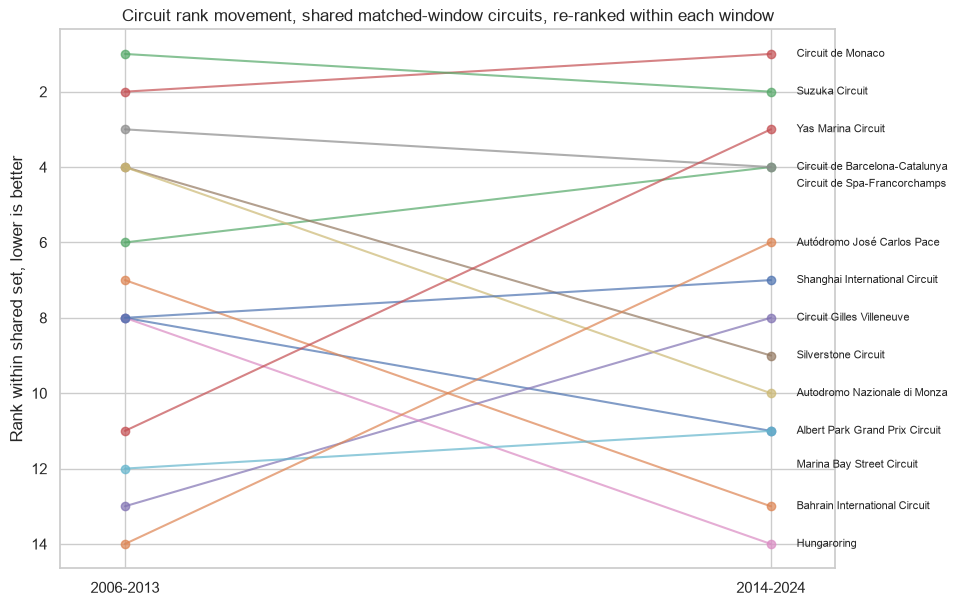

Q1 full-history sensitivity, circuits only pre-2014:


,circuitId,circuit_name,circuit_country
39,8,Circuit de Nevers Magny-Cours,France
36,5,Istanbul Park,Turkey
50,19,Indianapolis Motor Speedway,USA
71,41,Dijon-Prenois,France
33,2,Sepang International Circuit,Malaysia
57,27,Autódromo do Estoril,Portugal
56,26,Circuito de Jerez,Spain
88,58,Aintree,UK
96,66,Circuit Bremgarten,Switzerland
73,43,Long Beach,USA


Q1 full-history sensitivity, circuits only 2014+:


,circuitId,circuit_name,circuit_country
24,71,Sochi Autodrom,Russia
22,69,Circuit of the Americas,USA
25,73,Baku City Circuit,Azerbaijan


Q1 full-history sensitivity rank stability (all seasons, pre-2014 vs 2014+):
Q1 full-history Spearman rho=-0.083, p=0.7590
Q1 full-history Kendall tau=-0.051, p=0.7862
Q1 sampling-noise benchmark for Spearman (full-history sensitivity):


,metric,value
0,observed_spearman,-0.083333
1,noise_median,0.392172
2,noise_ci_low,-0.074740
3,noise_ci_high,0.755209
4,observed_noise_percentile,0.021500
5,circuits,16.000000


Q1 circuits in only one matched window: Red Bull Ring
Saved figure: figures_de/q1_front_row_grid_conversion.png


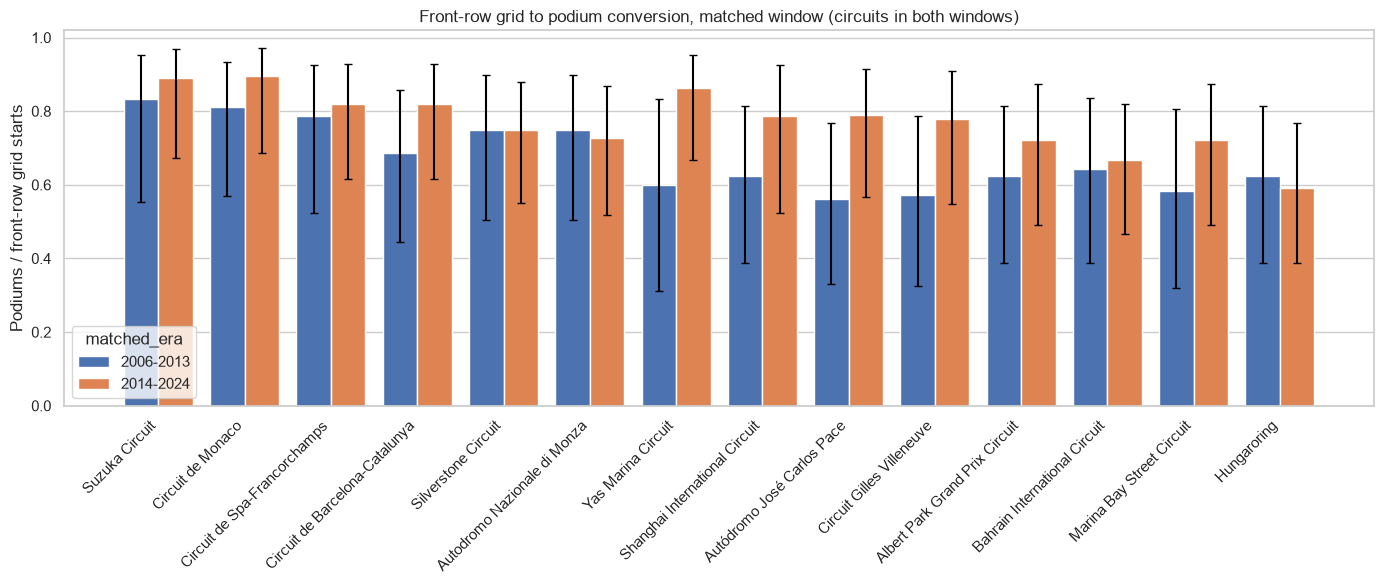

Q1 all-years sensitivity table (n>=10; small samples included): (48, 8)


,circuitId,circuit_name,circuit_country,starts,podiums,conversion,conversion_ci_low,conversion_ci_high
67,69,Circuit of the Americas,USA,24,20,0.833333,0.641469,0.933213
7,8,Circuit de Nevers Magny-Cours,France,35,29,0.828571,0.673177,0.918974
69,71,Sochi Autodrom,Russia,16,13,0.8125,0.569911,0.934084
18,19,Indianapolis Motor Speedway,USA,14,11,0.785714,0.524108,0.924286
22,24,Yas Marina Circuit,UAE,32,25,0.78125,0.612450,0.889762
21,22,Suzuka Circuit,Japan,68,51,0.75,0.635614,0.837650
39,41,Dijon-Prenois,France,12,9,0.75,0.467695,0.911058
1,2,Sepang International Circuit,Malaysia,37,27,0.72973,0.570218,0.846025
4,5,Istanbul Park,Turkey,18,13,0.722222,0.491273,0.875002
3,4,Circuit de Barcelona-Catalunya,Spain,67,48,0.716418,0.599068,0.810297


In [ ]:
# Q1 rank stability and matched-window headline: headline statistics use the matched-window table restricted to circuits present in both windows; full-history statistics remain as a labelled sensitivity check.
de_q1_matched_pre_label = f"{de_matched_pre_start_year}-{de_matched_pre_end_year}"
de_q1_matched_post_label = f"{de_matched_post_start_year}-{de_matched_post_end_year}"
de_q1_matched = de_q1.loc[de_q1["year"].between(de_matched_pre_start_year, de_matched_post_end_year)].copy()
de_q1_matched["matched_era"] = np.select([de_q1_matched["year"].between(de_matched_pre_start_year, de_matched_pre_end_year), de_q1_matched["year"].between(de_matched_post_start_year, de_matched_post_end_year)], [de_q1_matched_pre_label, de_q1_matched_post_label], default=None)
de_q1_matched_table = de_rank_conversion(de_q1_matched.dropna(subset=["matched_era"]), "front_row_grid", "matched_era", de_min_n)
de_q1_matched_headline_circuits = de_q1_matched_table.groupby("circuitId")["starts"].sum().loc[lambda de_s: de_s.ge(de_min_n_q1_headline)].index
de_q1_matched_headline_table = de_q1_matched_table.loc[de_q1_matched_table["circuitId"].isin(de_q1_matched_headline_circuits)].copy()
de_q1_matched_headline_table["rank"] = de_q1_matched_headline_table.groupby("matched_era")["conversion"].rank(ascending=False, method="min")
de_q1_matched_headline_table = de_q1_matched_headline_table.sort_values(["matched_era","rank","starts"], ascending=[True,True,False])
print(f"Q1 matched-window headline table (n>={de_min_n_q1_headline} total front-row starts across matched windows):", de_q1_matched_headline_table.shape); display(de_q1_matched_headline_table)
print(f"Q1 matched-window small-sample table (n>={de_min_n} front-row starts):", de_q1_matched_table.shape); display(de_q1_matched_table)
print("Q1 sensitivity note: full-history and same-rows tables can disagree because they use different eras and have qualifying-coverage gaps.")

de_q1_rng = np.random.default_rng(20261008)

def de_rank_stability(de_table, de_era_col, de_era_a, de_era_b):
    de_wide = de_table.pivot(index="circuitId", columns=de_era_col, values="rank").dropna()
    de_spearman = spearmanr(de_wide[de_era_a], de_wide[de_era_b])
    de_kendall = kendalltau(de_wide[de_era_a], de_wide[de_era_b])
    de_counts_wide = de_table.loc[de_table["circuitId"].isin(set(de_wide.index)), [de_era_col,"circuitId","starts","podiums"]].pivot(index="circuitId", columns=de_era_col, values=["starts","podiums"]).dropna()
    de_n = len(de_counts_wide)
    de_true_rate = (de_counts_wide[("podiums",de_era_a)] + de_counts_wide[("podiums",de_era_b)]) / (de_counts_wide[("starts",de_era_a)] + de_counts_wide[("starts",de_era_b)])
    de_boot = []
    for de_i in range(2000):
        de_a_sim = de_q1_rng.binomial(de_counts_wide[("starts",de_era_a)].astype(int).to_numpy(), de_true_rate.to_numpy(dtype=float)) / de_counts_wide[("starts",de_era_a)].to_numpy(dtype=float)
        de_b_sim = de_q1_rng.binomial(de_counts_wide[("starts",de_era_b)].astype(int).to_numpy(), de_true_rate.to_numpy(dtype=float)) / de_counts_wide[("starts",de_era_b)].to_numpy(dtype=float)
        de_boot.append(spearmanr(pd.Series(de_a_sim).rank(ascending=False, method="min"), pd.Series(de_b_sim).rank(ascending=False, method="min")).statistic)
    de_boot = np.array(de_boot, dtype=float)
    de_ci_low = float(np.nanquantile(de_boot, .025))
    de_ci_high = float(np.nanquantile(de_boot, .975))
    de_percentile = float(np.nanmean(de_boot <= de_spearman.statistic))
    de_summary = pd.DataFrame({"metric":["observed_spearman","noise_median","noise_ci_low","noise_ci_high","observed_noise_percentile","circuits"], "value":[de_spearman.statistic, np.nanmedian(de_boot), de_ci_low, de_ci_high, de_percentile, de_n]})
    return de_wide, de_spearman, de_kendall, de_ci_low, de_ci_high, de_percentile, de_n, de_summary

de_q1_wide, de_q1_spearman, de_q1_kendall, de_q1_noise_ci_low, de_q1_noise_ci_high, de_q1_observed_noise_percentile, de_q1_noise_n, de_q1_noise_summary = de_rank_stability(de_q1_matched_headline_table, "matched_era", de_q1_matched_pre_label, de_q1_matched_post_label)
print(f"Q1 headline rank stability, matched window {de_q1_matched_pre_label} vs {de_q1_matched_post_label}, circuits in both windows: {de_q1_noise_n}")
print(f"Q1 Spearman rho={de_q1_spearman.statistic:.3f}, p={de_q1_spearman.pvalue:.4f}")
print(f"Q1 Kendall tau={de_q1_kendall.statistic:.3f}, p={de_q1_kendall.pvalue:.4f}")
print("Q1 sampling-noise benchmark for Spearman (matched-window headline):"); display(de_q1_noise_summary)

de_q1_slope = de_q1_matched_headline_table.loc[de_q1_matched_headline_table["circuitId"].isin(set(de_q1_wide.index)), ["matched_era","circuitId","circuit_name","conversion"]].copy()
de_q1_slope["shared_rank"] = de_q1_slope.groupby("matched_era")["conversion"].rank(ascending=False, method="min")
de_era_to_x = {de_q1_matched_pre_label: 0, de_q1_matched_post_label: 1}
de_fig, de_ax = plt.subplots(figsize=(10,7))
de_label_used_y = []
for de_circuit_id, de_sub in de_q1_slope.groupby("circuitId"):
    de_sub = de_sub.sort_values("matched_era")
    de_ax.plot([de_era_to_x[de_e] for de_e in de_sub["matched_era"]], de_sub["shared_rank"], marker="o", alpha=.7)
    de_post_row = de_sub.loc[de_sub["matched_era"].eq(de_q1_matched_post_label)]
    de_label_y = float(de_post_row["shared_rank"].iloc[0])
    while any(abs(de_label_y - de_used_y) < 0.45 for de_used_y in de_label_used_y):
        de_label_y += 0.45
    de_label_used_y.append(de_label_y)
    de_ax.text(1.04, de_label_y, str(de_post_row["circuit_name"].iloc[0]), fontsize=8, va="center")
de_ax.set_xticks([0,1]); de_ax.set_xticklabels([de_q1_matched_pre_label, de_q1_matched_post_label])
de_ax.set_xlim(-0.1, 1.1)
de_ax.invert_yaxis(); de_ax.set_title("Circuit rank movement, shared matched-window circuits, re-ranked within each window"); de_ax.set_ylabel("Rank within shared set, lower is better"); de_ax.set_xlabel("")
de_save_show(de_fig, "q1_rank_slope.png")

de_q1_pre_set = set(de_q1_grid_table.loc[de_q1_grid_table["era_pre_2014"].eq("pre-2014"), "circuitId"])
de_q1_post_set = set(de_q1_grid_table.loc[de_q1_grid_table["era_pre_2014"].eq("2014+"), "circuitId"])
de_q1_only_pre = de_q1_grid_table.loc[de_q1_grid_table["circuitId"].isin(de_q1_pre_set - de_q1_post_set), ["circuitId","circuit_name","circuit_country"]].drop_duplicates()
de_q1_only_post = de_q1_grid_table.loc[de_q1_grid_table["circuitId"].isin(de_q1_post_set - de_q1_pre_set), ["circuitId","circuit_name","circuit_country"]].drop_duplicates()
print("Q1 full-history sensitivity, circuits only pre-2014:"); display(de_q1_only_pre)
print("Q1 full-history sensitivity, circuits only 2014+:"); display(de_q1_only_post)
de_q1_full_wide, de_q1_full_spearman, de_q1_full_kendall, de_q1_full_noise_ci_low, de_q1_full_noise_ci_high, de_q1_full_observed_noise_percentile, de_q1_full_noise_n, de_q1_full_noise_summary = de_rank_stability(de_q1_grid_table, "era_pre_2014", "pre-2014", "2014+")
print("Q1 full-history sensitivity rank stability (all seasons, pre-2014 vs 2014+):")
print(f"Q1 full-history Spearman rho={de_q1_full_spearman.statistic:.3f}, p={de_q1_full_spearman.pvalue:.4f}")
print(f"Q1 full-history Kendall tau={de_q1_full_kendall.statistic:.3f}, p={de_q1_full_kendall.pvalue:.4f}")
print("Q1 sampling-noise benchmark for Spearman (full-history sensitivity):"); display(de_q1_full_noise_summary)

de_q1_shared_circuits = set(de_q1_wide.index)
de_q1_only_one_window = de_q1_matched_headline_table.loc[~de_q1_matched_headline_table["circuitId"].isin(de_q1_shared_circuits), "circuit_name"].drop_duplicates().sort_values().tolist()
print("Q1 circuits in only one matched window: " + (", ".join(de_q1_only_one_window) if de_q1_only_one_window else "none"))
de_q1_plot = de_q1_matched_headline_table.loc[de_q1_matched_headline_table["circuitId"].isin(de_q1_shared_circuits)].copy()
de_q1_order = de_q1_plot.groupby("circuit_name")["conversion"].mean().sort_values(ascending=False).index.tolist()
de_fig, de_ax = de_grouped_bar_ci(de_q1_plot, "circuit_name", "conversion", "conversion_ci_low", "conversion_ci_high", "matched_era", de_q1_order, [de_q1_matched_pre_label, de_q1_matched_post_label], "Front-row grid to podium conversion, matched window (circuits in both windows)", "Podiums / front-row grid starts", 45, (14,6))
de_save_show(de_fig, "q1_front_row_grid_conversion.png")

de_q1_all_years = de_q1.loc[de_q1["front_row_grid"]].groupby(["circuitId","circuit_name","circuit_country"]).agg(starts=("podium","size"), podiums=("podium","sum")).reset_index()
de_q1_all_years["conversion"] = de_q1_all_years["podiums"] / de_q1_all_years["starts"]
de_q1_all_years = de_add_wilson(de_q1_all_years, "podiums", "starts", "conversion")
de_q1_all_years = de_q1_all_years.loc[de_q1_all_years["starts"] >= de_min_n].sort_values("conversion", ascending=False)
print(f"Q1 all-years sensitivity table (n>={de_min_n}; small samples included):", de_q1_all_years.shape); display(de_q1_all_years)


## Q1 note on grain, missingness, and pre-race cutoff

The grain is one cleaned `results` row per race-driver start. Missing qualifying positions are not imputed; qualifying front-row analysis is limited to seasons with at least 90% coverage. `positionOrder` creates the retrospective podium outcome and is never a pre-race model feature.

In [ ]:
# Q1 printed answer: matched-window headline with tied winners, top/bottom circuits with Wilson CIs, computed CI-overlap statement, softened rank-stability wording, coverage ranges, and grid/qualifying mismatch shares.
def de_q1_top_with_ci_ties(de_table, de_era_col, de_era_value):
    de_sub = de_table.loc[de_table[de_era_col].eq(de_era_value)].sort_values(["rank","starts"], ascending=[True,False]).copy()
    de_top = de_sub.iloc[0]
    de_ties = de_sub.loc[(de_sub["circuitId"].ne(de_top["circuitId"])) & de_sub["conversion_ci_low"].le(de_top["conversion_ci_high"]) & de_sub["conversion_ci_high"].ge(de_top["conversion_ci_low"]), "circuit_name"].tolist()
    de_name = f"{de_top['circuit_name']} (statistically tied with {len(de_ties)} of {len(de_sub) - 1} other circuits, CI overlap)"
    de_detail = ", ".join(de_ties) if de_ties else "none"
    return de_top, de_name, de_detail

de_q1_matched_best_pre, de_q1_matched_best_pre_text, de_q1_matched_best_pre_ties_detail = de_q1_top_with_ci_ties(de_q1_matched_headline_table, "matched_era", de_q1_matched_pre_label)
de_q1_matched_best_post, de_q1_matched_best_post_text, de_q1_matched_best_post_ties_detail = de_q1_top_with_ci_ties(de_q1_matched_headline_table, "matched_era", de_q1_matched_post_label)
print(f"Q1 tied circuits (detail): {de_q1_matched_pre_label}: {de_q1_matched_best_pre_ties_detail}; {de_q1_matched_post_label}: {de_q1_matched_best_post_ties_detail}")
de_q1_same_rows_best_pre = de_q1_quali_table.loc[de_q1_quali_table["era_pre_2014"].eq("pre-2014")].head(1)
de_q1_same_rows_best_post = de_q1_quali_table.loc[de_q1_quali_table["era_pre_2014"].eq("2014+")].head(1)

de_q1_top_bottom_n = 3
def de_q1_top_bottom_text(de_table, de_era_value):
    de_sub = de_table.loc[de_table["matched_era"].eq(de_era_value)].sort_values(["rank","starts"], ascending=[True,False])
    def de_fmt(de_row):
        return f"{de_row.circuit_name} {de_row.conversion:.1%} [{de_row.conversion_ci_low:.1%}, {de_row.conversion_ci_high:.1%}]"
    de_top_text = "; ".join(de_fmt(de_row) for de_row in de_sub.head(de_q1_top_bottom_n).itertuples())
    de_bottom_text = "; ".join(de_fmt(de_row) for de_row in de_sub.tail(de_q1_top_bottom_n).itertuples())
    return de_top_text, de_bottom_text

de_q1_top_pre_text, de_q1_bottom_pre_text = de_q1_top_bottom_text(de_q1_matched_headline_table, de_q1_matched_pre_label)
de_q1_top_post_text, de_q1_bottom_post_text = de_q1_top_bottom_text(de_q1_matched_headline_table, de_q1_matched_post_label)

def de_q1_ci_overlap_share(de_table, de_era_value):
    de_sub = de_table.loc[de_table["matched_era"].eq(de_era_value)].reset_index(drop=True)
    de_pairs = 0
    de_overlap = 0
    for de_i in range(len(de_sub)):
        for de_j in range(de_i + 1, len(de_sub)):
            de_pairs += 1
            de_overlap += int(bool(de_sub.loc[de_i, "conversion_ci_low"] <= de_sub.loc[de_j, "conversion_ci_high"] and de_sub.loc[de_j, "conversion_ci_low"] <= de_sub.loc[de_i, "conversion_ci_high"]))
    return de_overlap / de_pairs if de_pairs else float("nan")

de_q1_overlap_share_pre = de_q1_ci_overlap_share(de_q1_matched_headline_table, de_q1_matched_pre_label)
de_q1_overlap_share_post = de_q1_ci_overlap_share(de_q1_matched_headline_table, de_q1_matched_post_label)
if min(de_q1_overlap_share_pre, de_q1_overlap_share_post) > 0.5:
    de_q1_overlap_text = f"Most circuit Wilson CIs overlap within each window ({de_q1_overlap_share_pre:.0%} of circuit pairs in {de_q1_matched_pre_label} and {de_q1_overlap_share_post:.0%} in {de_q1_matched_post_label}), so the ordering within a window is noisy."
else:
    de_q1_overlap_text = f"Fewer than half of circuit Wilson CI pairs overlap in at least one window ({de_q1_overlap_share_pre:.0%} of circuit pairs in {de_q1_matched_pre_label} and {de_q1_overlap_share_post:.0%} in {de_q1_matched_post_label}), so some ordering differences are clearer."

if de_q1_spearman.statistic < de_q1_noise_ci_low:
    de_q1_bootstrap_interpretation = f"The observed Spearman rho is {de_q1_spearman.statistic:.2f}, below the sampling-noise 95% range [{de_q1_noise_ci_low:.2f}, {de_q1_noise_ci_high:.2f}] with observed percentile {de_q1_observed_noise_percentile:.3f}; this is only weak, suggestive evidence that the circuit ordering may have shifted between the matched windows, especially because most circuit CIs overlap and only {de_q1_noise_n} circuits appear in both windows."
elif de_q1_spearman.statistic <= de_q1_noise_ci_high:
    de_q1_bootstrap_interpretation = f"The observed Spearman rho is {de_q1_spearman.statistic:.2f}, inside the sampling-noise 95% range [{de_q1_noise_ci_low:.2f}, {de_q1_noise_ci_high:.2f}] with observed percentile {de_q1_observed_noise_percentile:.3f}; the rank movement remains compatible with sampling noise, especially with only {de_q1_noise_n} circuits in both windows."
else:
    de_q1_bootstrap_interpretation = f"The observed Spearman rho is {de_q1_spearman.statistic:.2f}, above the sampling-noise 95% range [{de_q1_noise_ci_low:.2f}, {de_q1_noise_ci_high:.2f}] with observed percentile {de_q1_observed_noise_percentile:.3f}; the rank ordering looks broadly stable across the matched windows, though only {de_q1_noise_n} circuits appear in both."

de_q1_matched_inside_noise = de_q1_noise_ci_low <= de_q1_spearman.statistic <= de_q1_noise_ci_high
de_q1_full_inside_noise = de_q1_full_noise_ci_low <= de_q1_full_spearman.statistic <= de_q1_full_noise_ci_high
de_q1_full_history_sensitivity_text = f"Full-history sensitivity has Spearman rho {de_q1_full_spearman.statistic:.2f}, sampling-noise 95% range [{de_q1_full_noise_ci_low:.2f}, {de_q1_full_noise_ci_high:.2f}], observed percentile {de_q1_full_observed_noise_percentile:.3f}, across {de_q1_full_noise_n} circuits."
if de_q1_matched_inside_noise != de_q1_full_inside_noise:
    de_q1_robustness_verdict = "The matched-window and full-history analyses disagree, so the conclusion that circuit ranking changed after 2014 is not robust to the choice of window."
else:
    de_q1_robustness_verdict = "The matched-window and full-history analyses agree on whether the observed rank stability falls inside the sampling-noise range."

de_q1_window_starts = de_q1_matched_headline_table.groupby("matched_era")["starts"].agg(["min", "max"])
de_q1_window_starts_text = f"Per-window front-row starts among headline circuits range from {int(de_q1_window_starts.loc[de_q1_matched_pre_label, 'min'])}-{int(de_q1_window_starts.loc[de_q1_matched_pre_label, 'max'])} in {de_q1_matched_pre_label} and {int(de_q1_window_starts.loc[de_q1_matched_post_label, 'min'])}-{int(de_q1_window_starts.loc[de_q1_matched_post_label, 'max'])} in {de_q1_matched_post_label}; the n>={de_min_n_q1_headline} threshold is on starts summed across both matched windows, so per-window samples are small and wide CIs are expected."

de_q1_answer = (
    f"Q1 answer: The headline matched-window grid comparison uses at least {de_min_n_q1_headline} total front-row starts across the matched windows. "
    f"For {de_q1_matched_pre_label}, the top circuit is {de_q1_matched_best_pre_text} at {de_q1_matched_best_pre['conversion']:.1%} ({int(de_q1_matched_best_pre['podiums'])}/{int(de_q1_matched_best_pre['starts'])}). "
    f"For {de_q1_matched_post_label}, the top circuit is {de_q1_matched_best_post_text} at {de_q1_matched_best_post['conversion']:.1%} ({int(de_q1_matched_best_post['podiums'])}/{int(de_q1_matched_best_post['starts'])}). "
    "Circuits whose Wilson CI overlaps the top circuit's CI are statistically tied. "
    f"Top {de_q1_top_bottom_n} in {de_q1_matched_pre_label}: {de_q1_top_pre_text}. Bottom {de_q1_top_bottom_n} in {de_q1_matched_pre_label}: {de_q1_bottom_pre_text}. "
    f"Top {de_q1_top_bottom_n} in {de_q1_matched_post_label}: {de_q1_top_post_text}. Bottom {de_q1_top_bottom_n} in {de_q1_matched_post_label}: {de_q1_bottom_post_text}. "
    + de_q1_overlap_text + " "
    + de_q1_window_starts_text + " "
    f"The same-rows qualifying sensitivity uses covered seasons only; its top qualifying-position circuits are {de_q1_same_rows_best_pre.iloc[0]['circuit_name']} before 2014 and {de_q1_same_rows_best_post.iloc[0]['circuit_name']} from 2014 onward. "
    f"Rank stability is assessed on the matched-window headline circuits ({de_q1_noise_n} in both windows); full-history statistics are reported as a sensitivity check. "
    + de_q1_bootstrap_interpretation + " "
    + de_q1_full_history_sensitivity_text + " "
    + de_q1_robustness_verdict + " "
    f"Qualifying coverage at the {de_quali_coverage_threshold:.0%} threshold occurs in {de_q1_coverage_ranges_text}; gap {de_q1_coverage_gap_text}. "
    f"Grid differs from qualifying position in {de_q1_grid_quali_mismatch_share:.1%} of qualifying-covered rows including grid=0 and {de_q1_grid_quali_mismatch_share_ex_grid0:.1%} excluding grid=0. "
    "Full-history and same-rows sensitivity checks can disagree with the matched-window headline because they use different eras and have qualifying-coverage gaps."
)
print(de_q1_answer)


Q1 tied circuits (detail): 2006-2013: Circuit de Monaco, Circuit de Spa-Francorchamps, Silverstone Circuit, Autodromo Nazionale di Monza, Circuit de Barcelona-Catalunya, Bahrain International Circuit, Albert Park Grand Prix Circuit, Hungaroring, Shanghai International Circuit, Yas Marina Circuit, Marina Bay Street Circuit, Circuit Gilles Villeneuve, Autódromo José Carlos Pace; 2014-2024: Suzuka Circuit, Yas Marina Circuit, Circuit de Barcelona-Catalunya, Circuit de Spa-Francorchamps, Autódromo José Carlos Pace, Shanghai International Circuit, Circuit Gilles Villeneuve, Silverstone Circuit, Red Bull Ring, Autodromo Nazionale di Monza, Albert Park Grand Prix Circuit, Marina Bay Street Circuit, Bahrain International Circuit, Hungaroring
Q1 answer: The headline matched-window grid comparison uses at least 25 total front-row starts across the matched windows. For 2006-2013, the top circuit is Suzuka Circuit (statistically tied with 13 of 13 other circuits, CI overlap) at 83.3% (10/12). For 

## Q1 written answer

The headline comparison is `de_q1_matched_headline_table`, which compares the matched windows `de_matched_pre_start_year`-`de_matched_pre_end_year` and `de_matched_post_start_year`-`de_matched_post_end_year` for circuits with at least `de_min_n_q1_headline` total front-row starts across those matched windows. The printed answer reports the top circuit for each matched window and appends tied circuits when their Wilson interval overlaps the top circuit's Wilson interval, then lists the top and bottom `de_q1_top_bottom_n` circuits per window with conversion and Wilson interval. It also states whether most circuit Wilson CIs overlap, computed from the share of circuit pairs with overlapping intervals (`de_q1_overlap_share_pre`, `de_q1_overlap_share_post`).

Rank stability (Spearman, Kendall, and the sampling-noise bootstrap in `de_rank_stability`) is computed on the headline matched-window table, restricted to circuits present in both windows (`de_q1_wide`). The full-history equivalents (`de_q1_full_spearman`, `de_q1_full_kendall`, `de_q1_full_noise_summary`) remain displayed as labelled sensitivity checks, alongside the `n>=10` small-sample tables `de_q1_grid_table`, `de_q1_grid_same_rows_table`, and `de_q1_quali_table`; they can disagree with the matched-window headline because they use different eras and because qualifying coverage has gaps. The slope chart `q1_rank_slope.png` re-ranks only the shared circuits within each window, puts the earlier window on the left, and labels each line with the circuit name.

The bootstrap interpretation in `de_q1_answer` is generated from the matched-window statistics (`de_q1_spearman.statistic`, `de_q1_noise_ci_low`, `de_q1_noise_ci_high`, `de_q1_observed_noise_percentile`, `de_q1_noise_n`). If the observed Spearman is below the noise interval, the wording is deliberately softened: only weak, suggestive evidence that the ordering may have shifted, because most circuit CIs overlap and few circuits appear in both windows.

Grain: one cleaned `results` row per `(raceId, driverId)`, joined to race, circuit, and qualifying rows using checked merges. Missingness: qualifying position coverage is reported by season, and same-rows comparisons use only non-null qualifying rows in covered seasons. Pre-race cutoff: grid and qualifying position are known before the race; podium is the retrospective outcome.


The bar chart `q1_front_row_grid_conversion.png` now plots only circuits that appear in both matched windows (`de_q1_wide.index`), ordered by their mean conversion rate across the two windows. Circuits appearing in only one matched window are printed separately as `Q1 circuits in only one matched window: ...` and are not plotted.

The printed answer now reports CI-overlap ties as counts instead of long parenthetical circuit lists, with the full tied-circuit detail printed separately. It also adds a computed full-history sensitivity sentence, a robustness verdict comparing matched-window and full-history noise-range conclusions, and a computed note that the `de_min_n_q1_headline` threshold is based on starts summed across both windows while per-window samples remain small.


# Q2. Home-country podium rate

The home-country flag is built by set membership from `nationality_country`, not by merging that multi-row table into result rows.

Q2 results -> drivers: before=(24566, 7), after=(24566, 8)
Q2 -> races: before=(24566, 8), after=(24566, 10)
Q2 -> circuits: before=(24566, 10), after=(24566, 11)
Q2 home-race row share: 0.0786
Q2 drivers whose nationality can ever have a home race: 640
Q2 mapped hosted home countries: 26
Q2 nationalities mapped to multiple home countries: 4
Q2 raw home vs away comparison:


,home_status,podiums,starts,podium_rate,podium_rate_ci_low,podium_rate_ci_high
0,Away,3118,22634,0.137757,0.133329,0.142309
1,Home,224,1932,0.115942,0.102422,0.130986


Q2 stratified table: (12, 7)


,grid_bucket,is_home,starts,podiums,podium_rate,podium_rate_ci_low,podium_rate_ci_high
0,pit lane,False,83,0,0.0,0.000000,0.044235
1,pit lane,True,4,0,0.0,0.000000,0.489891
2,1-3,False,3105,1725,0.555556,0.538020,0.572954
3,1-3,True,230,128,0.556522,0.491912,0.619274
4,4-6,False,3107,810,0.260702,0.245567,0.276427
5,4-6,True,226,60,0.265487,0.212183,0.326630
6,7-10,False,4090,379,0.092665,0.084157,0.101938
7,7-10,True,335,24,0.071642,0.048613,0.104384
8,11-15,False,5091,151,0.02966,0.025343,0.034687
9,11-15,True,414,10,0.024155,0.013172,0.043886


Saved figure: figures_de/q2_home_away_grid_bucket.png


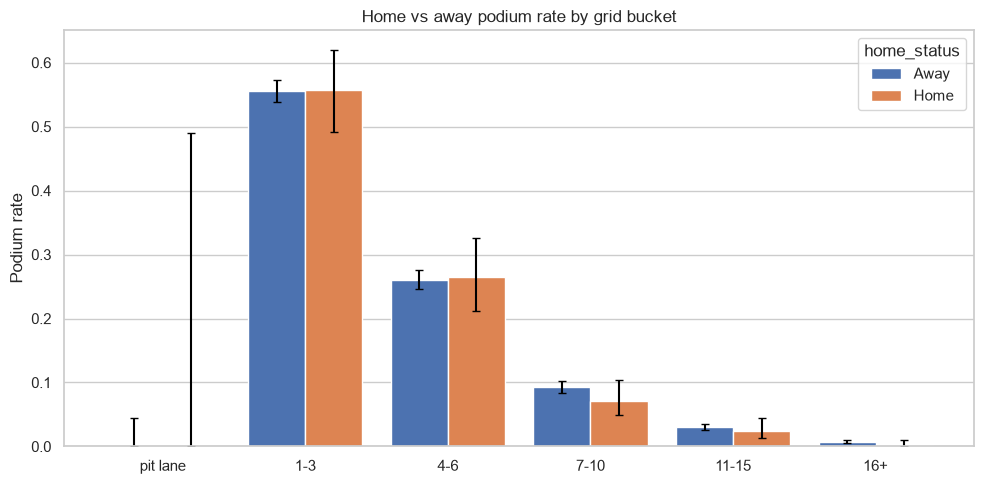

Q2 grid levels excluded from logit because outcome has no variation: ['pit lane']
Q2 constructor levels excluded from constructor logit because outcome has no variation: 42
Q2 controlled model table: (5, 6)


,model,effect_type,estimate,ci_low,ci_high,p_value
0,"Logit: grid position, clustered by race",odds_ratio,0.923082,0.780190,1.092144,0.350948
1,"Logit: grid + era + constructor, separated lev...",odds_ratio,0.978278,0.822711,1.163263,0.803725
2,"LPM: grid + constructor-season FE, clustered b...",coefficient,-0.005454,-0.017982,0.007075,0.393577
3,"LPM: grid + driver FE, clustered by race",coefficient,-0.001173,-0.014733,0.012388,0.865423
4,"Logit: grid position, year >= 2006, clustered ...",odds_ratio,0.877287,0.552662,1.392590,0.578683


Saved figure: figures_de/q2_home_odds_ratio_forest.png


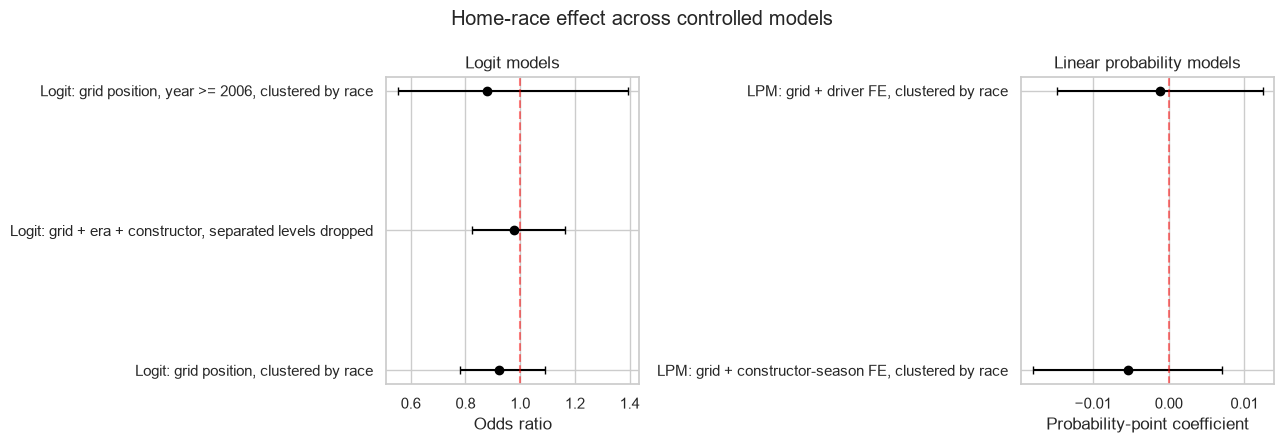

In [ ]:
de_df = tables["results"].copy()
de_q2 = de_df[["resultId","raceId","driverId","constructorId","grid","positionOrder"]].copy()
de_q2["podium"] = de_q2["positionOrder"].le(3)
de_q2 = de_checked_merge(de_q2, tables["drivers"][["driverId","nationality"]].copy(), on="driverId", how="left", validate="many_to_one", name="Q2 results -> drivers")
de_q2 = de_checked_merge(de_q2, tables["races"][["raceId","year","circuitId"]].copy(), on="raceId", how="left", validate="many_to_one", name="Q2 -> races")
de_q2 = de_checked_merge(de_q2, tables["circuits"][["circuitId","country"]].copy().rename(columns={"country":"circuit_country"}), on="circuitId", how="left", validate="many_to_one", name="Q2 -> circuits")
de_q2["era_pre_2014"] = de_era_pre_2014(de_q2["year"])
de_nat_country = tables["nationality_country"][["nationality","country","hosted_a_race"]].copy().dropna(subset=["nationality","country"])
de_country_sets = de_nat_country.groupby("nationality")["country"].agg(lambda de_s: set(de_s.dropna())).to_dict()
de_q2_rows_before_home = len(de_q2)
de_q2["is_home"] = [de_country in de_country_sets.get(de_nat, set()) for de_nat, de_country in zip(de_q2["nationality"], de_q2["circuit_country"])]
assert len(de_q2) == de_q2_rows_before_home
de_q2_home_share = float(de_q2["is_home"].mean())
de_q2_hosted_nat = de_nat_country.loc[de_nat_country["hosted_a_race"].astype(bool)]
de_q2_multi_home_nationalities = de_nat_country.groupby("nationality")["country"].nunique().loc[lambda de_s: de_s.gt(1)]
print("Q2 home-race row share:", round(de_q2_home_share, 4))
print("Q2 drivers whose nationality can ever have a home race:", int(de_q2.loc[de_q2["nationality"].isin(set(de_q2_hosted_nat["nationality"])), "driverId"].nunique()))
print("Q2 mapped hosted home countries:", int(de_q2_hosted_nat["country"].nunique()))
print("Q2 nationalities mapped to multiple home countries:", int(len(de_q2_multi_home_nationalities)))

de_q2_raw = de_q2.groupby("is_home").agg(starts=("podium","size"), podiums=("podium","sum")).reset_index()
de_q2_raw["podium_rate"] = de_q2_raw["podiums"] / de_q2_raw["starts"]
de_q2_raw = de_add_wilson(de_q2_raw, "podiums", "starts", "podium_rate")
de_q2_raw["home_status"] = np.where(de_q2_raw["is_home"], "Home", "Away")
print("Q2 raw home vs away comparison:"); display(de_q2_raw[["home_status","podiums","starts","podium_rate","podium_rate_ci_low","podium_rate_ci_high"]])

de_grid_labels = ["pit lane","1-3","4-6","7-10","11-15","16+"]
de_q2["grid_bucket"] = pd.cut(de_q2["grid"], bins=[0,3,6,10,15,np.inf], labels=de_grid_labels[1:], include_lowest=True)
de_q2["grid_bucket"] = de_q2["grid_bucket"].astype(object)
de_q2.loc[de_q2["grid"].eq(0), "grid_bucket"] = "pit lane"
de_q2["grid_bucket"] = pd.Categorical(de_q2["grid_bucket"], categories=de_grid_labels, ordered=True)
de_q2_strata = de_q2.dropna(subset=["grid_bucket"]).groupby(["grid_bucket","is_home"], observed=True).agg(starts=("podium","size"), podiums=("podium","sum")).reset_index()
de_q2_strata["podium_rate"] = de_q2_strata["podiums"] / de_q2_strata["starts"]
de_q2_strata = de_add_wilson(de_q2_strata, "podiums", "starts", "podium_rate")
assert int(de_q2_strata["starts"].sum()) == len(de_q2.dropna(subset=["grid_bucket"]))
print("Q2 stratified table:", de_q2_strata.shape); display(de_q2_strata)
de_q2_plot = de_q2_strata.copy(); de_q2_plot["home_status"] = np.where(de_q2_plot["is_home"], "Home", "Away")
de_fig, de_ax = de_grouped_bar_ci(de_q2_plot, "grid_bucket", "podium_rate", "podium_rate_ci_low", "podium_rate_ci_high", "home_status", de_grid_labels, ["Away","Home"], "Home vs away podium rate by grid bucket", "Podium rate", 0, (10,5))
de_save_show(de_fig, "q2_home_away_grid_bucket.png")

de_q2_model = de_q2.dropna(subset=["grid_bucket","is_home","podium"]).copy()
de_q2_model["is_home_int"] = de_q2_model["is_home"].astype(int)
de_q2_model["podium_int"] = de_q2_model["podium"].astype(int)
de_q2_model["grid_position_model"] = np.select([de_q2_model["grid"].eq(0), de_q2_model["grid"].between(1,20), de_q2_model["grid"].gt(20)], ["pit lane", de_q2_model["grid"].astype("Int64").astype(str), "21+"], default=np.nan)
de_q2_model["era_model"] = de_q2_model["era_pre_2014"].astype(str)
de_q2_grid_variation = de_q2_model.groupby("grid_position_model")["podium_int"].agg(["size","sum"]).reset_index()
de_q2_separated_grid_levels = de_q2_grid_variation.loc[de_q2_grid_variation["sum"].isin([0]) | de_q2_grid_variation["sum"].eq(de_q2_grid_variation["size"]), "grid_position_model"].tolist()
de_q2_logit_model = de_q2_model.loc[~de_q2_model["grid_position_model"].isin(de_q2_separated_grid_levels)].copy()
print("Q2 grid levels excluded from logit because outcome has no variation:", de_q2_separated_grid_levels)

de_q2_logit = smf.logit("podium_int ~ is_home_int + C(grid_position_model)", data=de_q2_logit_model).fit(disp=False, maxiter=500, cov_type="cluster", cov_kwds={"groups": de_q2_logit_model["raceId"]})
de_q2_or = float(np.exp(de_q2_logit.params["is_home_int"]))
de_q2_ci = np.exp(de_q2_logit.conf_int().loc["is_home_int"])
de_q2_logit_2006_model = de_q2_logit_model.loc[de_q2_logit_model["year"].ge(de_matched_pre_start_year)].copy()
de_q2_logit_2006 = smf.logit("podium_int ~ is_home_int + C(grid_position_model)", data=de_q2_logit_2006_model).fit(disp=False, maxiter=500, cov_type="cluster", cov_kwds={"groups": de_q2_logit_2006_model["raceId"]})
de_q2_or_2006 = float(np.exp(de_q2_logit_2006.params["is_home_int"]))
de_q2_ci_2006 = np.exp(de_q2_logit_2006.conf_int().loc["is_home_int"])
de_q2_constructor_counts = de_q2_logit_model["constructorId"].value_counts()
de_q2_logit_model["constructor_model"] = de_q2_logit_model["constructorId"].where(de_q2_logit_model["constructorId"].map(de_q2_constructor_counts).ge(de_min_n), other=-1).astype(int).astype(str)
de_q2_constructor_variation = de_q2_logit_model.groupby("constructor_model")["podium_int"].agg(["size","sum"]).reset_index()
de_q2_separated_constructor_levels = de_q2_constructor_variation.loc[de_q2_constructor_variation["sum"].isin([0]) | de_q2_constructor_variation["sum"].eq(de_q2_constructor_variation["size"]), "constructor_model"].tolist()
de_q2_constructor_logit_model = de_q2_logit_model.loc[~de_q2_logit_model["constructor_model"].isin(de_q2_separated_constructor_levels)].copy()
print("Q2 constructor levels excluded from constructor logit because outcome has no variation:", len(de_q2_separated_constructor_levels))
de_q2_robust_logit = smf.logit("podium_int ~ is_home_int + C(grid_position_model) + C(era_model) + C(constructor_model)", data=de_q2_constructor_logit_model).fit(disp=False, maxiter=500, cov_type="cluster", cov_kwds={"groups": de_q2_constructor_logit_model["raceId"]})
de_q2_robust_or = float(np.exp(de_q2_robust_logit.params["is_home_int"]))
de_q2_robust_ci = np.exp(de_q2_robust_logit.conf_int().loc["is_home_int"])

de_q2_model["constructor_season"] = de_q2_model["constructorId"].astype(str) + "_" + de_q2_model["year"].astype(str)
de_q2_model["driver_model"] = de_q2_model["driverId"].astype(str)

def de_fit_lpm_fe(de_data, de_fe_col):
    de_x = pd.get_dummies(de_data["grid_position_model"], prefix="grid", drop_first=True, dtype=float)
    de_x.insert(0, "is_home_int", de_data["is_home_int"].astype(float).to_numpy())
    de_y = de_data["podium_int"].astype(float)
    de_fe = de_data[de_fe_col]
    de_x_resid = de_x - de_x.groupby(de_fe).transform("mean")
    de_y_resid = de_y - de_y.groupby(de_fe).transform("mean")
    de_keep_cols = de_x_resid.columns[de_x_resid.var().gt(0)]
    return sm.OLS(de_y_resid, de_x_resid[de_keep_cols]).fit(cov_type="cluster", cov_kwds={"groups": de_data["raceId"]})

de_q2_lpm_constructor_season = de_fit_lpm_fe(de_q2_model, "constructor_season")
de_q2_lpm_driver = de_fit_lpm_fe(de_q2_model, "driver_model")

de_q2_year_sensitivity_model_name = f"Logit: grid position, year >= {de_matched_pre_start_year}, clustered by race"
de_q2_or_table = pd.DataFrame({"model":["Logit: grid position, clustered by race","Logit: grid + era + constructor, separated levels dropped","LPM: grid + constructor-season FE, clustered by race","LPM: grid + driver FE, clustered by race",de_q2_year_sensitivity_model_name], "effect_type":["odds_ratio","odds_ratio","coefficient","coefficient","odds_ratio"], "estimate":[de_q2_or,de_q2_robust_or,float(de_q2_lpm_constructor_season.params["is_home_int"]),float(de_q2_lpm_driver.params["is_home_int"]),de_q2_or_2006], "ci_low":[float(de_q2_ci.iloc[0]),float(de_q2_robust_ci.iloc[0]),float(de_q2_lpm_constructor_season.conf_int().loc["is_home_int"].iloc[0]),float(de_q2_lpm_driver.conf_int().loc["is_home_int"].iloc[0]),float(de_q2_ci_2006.iloc[0])], "ci_high":[float(de_q2_ci.iloc[1]),float(de_q2_robust_ci.iloc[1]),float(de_q2_lpm_constructor_season.conf_int().loc["is_home_int"].iloc[1]),float(de_q2_lpm_driver.conf_int().loc["is_home_int"].iloc[1]),float(de_q2_ci_2006.iloc[1])], "p_value":[float(de_q2_logit.pvalues["is_home_int"]),float(de_q2_robust_logit.pvalues["is_home_int"]),float(de_q2_lpm_constructor_season.pvalues["is_home_int"]),float(de_q2_lpm_driver.pvalues["is_home_int"]),float(de_q2_logit_2006.pvalues["is_home_int"])]})
print("Q2 controlled model table:", de_q2_or_table.shape); display(de_q2_or_table)
de_q2_forest = de_q2_or_table.copy()
de_fig, de_axes = plt.subplots(1, 2, figsize=(13,4.5))
for de_ax, de_effect_type, de_reference, de_xlabel in [(de_axes[0], "odds_ratio", 1, "Odds ratio"), (de_axes[1], "coefficient", 0, "Probability-point coefficient")]:
    de_sub = de_q2_forest.loc[de_q2_forest["effect_type"].eq(de_effect_type)]
    de_ax.errorbar(de_sub["estimate"], de_sub["model"], xerr=[de_sub["estimate"]-de_sub["ci_low"], de_sub["ci_high"]-de_sub["estimate"]], fmt="o", color="black", capsize=3)
    de_ax.axvline(de_reference, color="red", linestyle="--", alpha=.5)
    de_ax.set_xlabel(de_xlabel)
de_axes[0].set_title("Logit models")
de_axes[1].set_title("Linear probability models")
de_fig.suptitle("Home-race effect across controlled models")
de_fig.tight_layout()
de_save_show(de_fig, "q2_home_odds_ratio_forest.png")


## Q2 note on grain, missingness, and pre-race cutoff

The grain is one cleaned `results` row per race-driver start. Missing nationality or circuit country values cannot create a home match. Podium is a post-race outcome used only retrospectively; final position and status are never model features.

In [ ]:
de_q2_raw_home = de_q2_raw.loc[de_q2_raw["is_home"]].iloc[0]
de_q2_raw_away = de_q2_raw.loc[~de_q2_raw["is_home"]].iloc[0]
de_q2_or_rows = de_q2_or_table.loc[de_q2_or_table["effect_type"].eq("odds_ratio")]
de_q2_lpm_rows = de_q2_or_table.loc[de_q2_or_table["effect_type"].eq("coefficient")]
de_q2_all_ci_include_null = bool(de_q2_or_rows["ci_low"].le(1).all() and de_q2_or_rows["ci_high"].ge(1).all() and de_q2_lpm_rows["ci_low"].le(0).all() and de_q2_lpm_rows["ci_high"].ge(0).all())
de_q2_model_summary_text = "; ".join(f"{de_row.model}: {de_row.estimate:.2f} [{de_row.ci_low:.2f}, {de_row.ci_high:.2f}]" for de_row in de_q2_or_rows.itertuples())
de_q2_lpm_summary_text = "; ".join(f"{de_row.model}: {de_row.estimate:.3f} [{de_row.ci_low:.3f}, {de_row.ci_high:.3f}]" for de_row in de_q2_lpm_rows.itertuples())
de_q2_year_sensitivity_row_pos = int(de_q2_or_table["model"].tolist().index(de_q2_year_sensitivity_model_name)) + 1
if de_q2_all_ci_include_null:
    de_q2_conclusion = "After controlling for grid position there is no detectable home-race advantage; the raw home<away gap is associated with differences in grid position, car quality, and local one-off entries. These are associations, not evidence of a causal home-race effect."
else:
    de_q2_conclusion = "At least one controlled model has a confidence interval excluding the null, so the controlled results are not uniformly consistent with no home-race effect."
de_q2_answer = (
    f"Q2 answer: Home-race rows are {de_q2_home_share:.1%} of cleaned race-driver starts. "
    f"Raw podium rates are {de_q2_raw_home['podium_rate']:.1%} at home ({int(de_q2_raw_home['podiums'])}/{int(de_q2_raw_home['starts'])}) and {de_q2_raw_away['podium_rate']:.1%} away ({int(de_q2_raw_away['podiums'])}/{int(de_q2_raw_away['starts'])}). "
    f"Odds-ratio models: {de_q2_model_summary_text}. "
    f"LPM sensitivities: {de_q2_lpm_summary_text}. "
    f"The year>={de_matched_pre_start_year} sensitivity is included as row {de_q2_year_sensitivity_row_pos} of de_q2_or_table. {de_q2_conclusion} "
    "Limitations: nationality is only a proxy for home race, dual-nationality mappings can assign more than one home country, home races are few, and association is not causation."
)
print(de_q2_answer)


Q2 answer: Home-race rows are 7.9% of cleaned race-driver starts. Raw podium rates are 11.6% at home (224/1932) and 13.8% away (3118/22634). Odds-ratio models: Logit: grid position, clustered by race: 0.92 [0.78, 1.09]; Logit: grid + era + constructor, separated levels dropped: 0.98 [0.82, 1.16]; Logit: grid position, year >= 2006, clustered by race: 0.88 [0.55, 1.39]. LPM sensitivities: LPM: grid + constructor-season FE, clustered by race: -0.005 [-0.018, 0.007]; LPM: grid + driver FE, clustered by race: -0.001 [-0.015, 0.012]. The year>=2006 sensitivity is included as row 5 of de_q2_or_table. After controlling for grid position there is no detectable home-race advantage; the raw home<away gap is associated with differences in grid position, car quality, and local one-off entries. These are associations, not evidence of a causal home-race effect. Limitations: nationality is only a proxy for home race, dual-nationality mappings can assign more than one home country, home races are few,

## Q2 written answer

The raw comparison is intentionally shown before controls: `de_q2_raw` reports home vs away podium rates with Wilson intervals. The controlled conclusion is generated in `de_q2_answer` from `de_q2_or_table`: odds-ratio rows are checked against 1 and linear-probability rows are checked against 0.

The controlled models use `grid=0` as its own pit-lane level in the descriptive stratification. For logit models, separated levels with no podium variation are excluded and the standard errors are clustered by `raceId`. The model table reports the base grid-position logit, a year `>=2006` grid-position sensitivity, a grid+era+constructor logit, a constructor-season fixed-effect linear probability model, and a within-driver fixed-effect linear probability model. The forest plot is split into two panels: logit-model odds ratios (reference line at 1) and linear-probability-model probability-point coefficients (reference line at 0), covering all five estimates.

Grain: one cleaned `results` row per `(raceId, driverId)`. Missingness: `grid`, `positionOrder`, race country, and driver nationality are available for the model rows after the checked joins. Pre-race cutoff: home status, circuit country, nationality, constructor, season, and grid are pre-race or entry attributes; podium is the retrospective outcome. Limitations: nationality is a proxy for home race, not birthplace or residence; dual nationalities are mapped to multiple home countries where the lookup table supplies them; and association is not causation.


# Q3. Mechanical-retirement rate by constructor

The denominator is starts: all cleaned result rows in 2014-2024, split into 2014-2021 and 2022-2024. Status is post-race and is used only for retrospective classification.

In [ ]:
de_df = tables["results"].copy()
de_q3 = de_df[["resultId","raceId","driverId","constructorId","statusId"]].copy()
assert de_q3["statusId"].notna().all()
de_q3 = de_checked_merge(de_q3, tables["status"][["statusId","status"]].copy(), on="statusId", how="left", validate="many_to_one", name="Q3 results -> status")
de_q3 = de_checked_merge(de_q3, tables["races"][["raceId","year"]].copy(), on="raceId", how="left", validate="many_to_one", name="Q3 -> races")
de_q3 = de_checked_merge(de_q3, tables["constructors"][["constructorId","name"]].copy().rename(columns={"name":"constructor_name"}), on="constructorId", how="left", validate="many_to_one", name="Q3 -> constructors")
de_q3 = de_q3.loc[de_q3["year"].between(de_hybrid_start_year, de_q3_new_end_year)].copy()
de_q3["q3_era"] = de_era_q3(de_q3["year"])
de_q3 = de_q3.dropna(subset=["q3_era"]).copy()
assert de_q3["statusId"].notna().all()
print(f"Q3 analysis shape after {de_hybrid_start_year}-{de_q3_new_end_year} filter:", de_q3.shape)
de_q3_status_counts = de_q3["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="count")
print("Q3 full status mapping input table sorted by count:")
with pd.option_context("display.max_rows", None):
    display(de_q3_status_counts)
de_q3_suspicious_statuses = de_q3_status_counts.loc[de_q3_status_counts["status"].astype(str).str.contains(r"Did not qualify|prequal|Withdrew|107%|Failed to qualify|Did not start|DNS", case=False, regex=True, na=False)]
print("Q3 suspicious non-start-like statuses after cleaning:"); display(de_q3_suspicious_statuses)

de_finished_statuses = {"Finished"}
de_mechanical_strict = {"Engine","Gearbox","Transmission","Clutch","Hydraulics","Electrical","Suspension","Brakes","Overheating","Fuel system","Oil leak","Water leak","Wheel","Wheel bearing","Fuel pressure","Fuel pump","Power Unit","ERS","Turbo","Battery","Electronics","Driveshaft","Axle","Radiator","Ignition","Oil pressure","Pneumatics","Power loss","MGU-K","MGU-H","Exhaust","Cooling system","Water pressure","Water pump","Fuel leak","Differential","Mechanical","Technical","Throttle","Steering","Drivetrain","Spark plugs","Brake duct"}
de_accident_driver = {"Accident","Collision","Collision damage","Spun off","Driver Seat","Physical","Injured","Illness","Driver unwell","Eye injury","Front wing","Rear wing","Seat"}
de_regulation = {"Disqualified","Excluded","Did not qualify","Did not prequalify","Withdrew","107% Rule","Not restarted","Safety concerns"}
de_ambiguous_lenient_mechanical = {"Retired","Damage","Puncture","Debris","Wheel nut","Vibrations","Tyre","Tyre puncture","Handling","Undertray","Floor","Bodywork","Out of fuel"}
de_ambiguous_other = set()

def de_status_category(de_status_value, de_lenient=False):
    if pd.isna(de_status_value): return "UNREVIEWED"
    de_text = str(de_status_value)
    if de_text in de_finished_statuses or re.fullmatch(r"\+\d+ Laps?", de_text): return "finished"
    if de_text in de_mechanical_strict: return "mechanical"
    if de_lenient and de_text in de_ambiguous_lenient_mechanical: return "mechanical"
    if de_text in de_accident_driver: return "accident-driver"
    if de_text in de_regulation: return "regulation"
    if de_text in de_ambiguous_lenient_mechanical or de_text in de_ambiguous_other: return "ambiguous-other"
    return "UNREVIEWED"

de_q3_status_mapping = de_q3_status_counts.copy()
de_q3_status_mapping["strict_category"] = de_q3_status_mapping["status"].map(lambda de_x: de_status_category(de_x, False))
de_q3_status_mapping["lenient_category"] = de_q3_status_mapping["status"].map(lambda de_x: de_status_category(de_x, True))
de_q3_status_mapping["ambiguous_note"] = np.where(de_q3_status_mapping["status"].isin(de_ambiguous_lenient_mechanical), "ambiguous; mechanical only in lenient mapping", "")
de_q3_unreviewed = de_q3_status_mapping.loc[de_q3_status_mapping[["strict_category","lenient_category"]].eq("UNREVIEWED").any(axis=1)]
print("Q3 UNREVIEWED statuses:"); display(de_q3_unreviewed)
assert de_q3_unreviewed.empty, "Review and classify all Q3 statuses before continuing"
de_q3_ambiguous_present = de_q3_status_mapping.loc[de_q3_status_mapping["ambiguous_note"].ne(""), ["status","count","strict_category","lenient_category"]].copy()
print("Q3 final documented status mapping table:")
with pd.option_context("display.max_rows", None):
    display(de_q3_status_mapping.sort_values(["strict_category","status"]))
print("Q3 ambiguous statuses present:"); display(de_q3_ambiguous_present)
de_q3["strict_category"] = de_q3["status"].map(lambda de_x: de_status_category(de_x, False))
de_q3["lenient_category"] = de_q3["status"].map(lambda de_x: de_status_category(de_x, True))
assert not de_q3[["strict_category","lenient_category"]].eq("UNREVIEWED").any().any()


Q3 results -> status: before=(24566, 5), after=(24566, 6)
Q3 -> races: before=(24566, 6), after=(24566, 7)
Q3 -> constructors: before=(24566, 7), after=(24566, 8)
Q3 analysis shape after 2014-2024 filter: (4595, 9)
Q3 full status mapping input table sorted by count:


,status,count
0,Finished,2403
1,+1 Lap,1178
2,+2 Laps,208
3,Collision,150
4,Accident,85
5,Engine,79
6,Collision damage,59
7,Retired,49
8,Brakes,48
9,Gearbox,40


Q3 suspicious non-start-like statuses after cleaning:


,status,count


Q3 UNREVIEWED statuses:


,status,count,strict_category,lenient_category,ambiguous_note


Q3 final documented status mapping table:


,status,count,strict_category,lenient_category,ambiguous_note
4,Accident,85,accident-driver,accident-driver,
3,Collision,150,accident-driver,accident-driver,
6,Collision damage,59,accident-driver,accident-driver,
36,Front wing,3,accident-driver,accident-driver,
48,Illness,2,accident-driver,accident-driver,
34,Rear wing,3,accident-driver,accident-driver,
53,Seat,1,accident-driver,accident-driver,
18,Spun off,11,accident-driver,accident-driver,
47,Damage,2,ambiguous-other,mechanical,ambiguous; mechanical only in lenient mapping
57,Debris,1,ambiguous-other,mechanical,ambiguous; mechanical only in lenient mapping


Q3 ambiguous statuses present:


,status,count,strict_category,lenient_category
7,Retired,49,ambiguous-other,mechanical
23,Puncture,7,ambiguous-other,mechanical
32,Tyre,4,ambiguous-other,mechanical
33,Undertray,4,ambiguous-other,mechanical
37,Wheel nut,3,ambiguous-other,mechanical
45,Vibrations,2,ambiguous-other,mechanical
47,Damage,2,ambiguous-other,mechanical
57,Debris,1,ambiguous-other,mechanical


Q3 constructor candidates in 2014-2024:


,constructorId,constructor_name
22028,51,Alfa Romeo
22447,213,AlphaTauri
22790,214,Alpine F1 Team
22787,117,Aston Martin
19986,207,Caterham
19973,6,Ferrari
19975,10,Force India
20750,210,Haas F1 Team
19984,208,Lotus F1
20403,209,Manor Marussia


Q3 constructor lineage table:


,constructorId,constructor_name,constructor_lineage
22028,51,Alfa Romeo,Sauber/Alfa Romeo/Sauber
22447,213,AlphaTauri,Toro Rosso/AlphaTauri/RB
22790,214,Alpine F1 Team,Lotus/Renault/Alpine
22787,117,Aston Martin,Force India/Racing Point/Aston Martin
19986,207,Caterham,Caterham
19973,6,Ferrari,Ferrari
19975,10,Force India,Force India/Racing Point/Aston Martin
20750,210,Haas F1 Team,Haas F1 Team
19984,208,Lotus F1,Lotus/Renault/Alpine
20403,209,Manor Marussia,Marussia/Manor Marussia


Q3 de_merge_lineages: True
Q3 strict by constructor name: (31, 8)


...

Q3 strict constructor era A -> era B: before=(10, 6), after=(10, 11)
Q3 lenient constructor era A -> era B: before=(10, 6), after=(10, 11)
Q3 strict per-constructor era change (full n>=10 table):


,constructor,starts_2014_2021,mechanical_2014_2021,rate_2014_2021,rate_2014_2021_ci_low,rate_2014_2021_ci_high,starts_2022_2024,mechanical_2022_2024,rate_2022_2024,rate_2022_2024_ci_low,rate_2022_2024_ci_high,rate_delta_2022_2024_minus_2014_2021,rate_delta_ci_low,rate_delta_ci_high
5,Sauber/Alfa Romeo/Sauber,319,26,0.081505,0.056226,0.116743,136,12,0.088235,0.051195,0.147898,0.006731,-0.044394,0.071528
9,Mercedes,320,12,0.037500,0.021580,0.064393,136,6,0.044118,0.020374,0.092908,0.006618,-0.029257,0.057939
8,Ferrari,318,18,0.056604,0.036101,0.087691,134,6,0.044776,0.020680,0.094245,-0.011828,-0.051160,0.041721
6,Williams,319,24,0.075235,0.051076,0.109503,134,7,0.052239,0.025532,0.103903,-0.022996,-0.066442,0.034037
7,Force India/Racing Point/Aston Martin,317,18,0.056782,0.036216,0.087962,133,4,0.030075,0.011757,0.074778,-0.026707,-0.062870,0.022499
1,Lotus/Renault/Alpine,318,44,0.138365,0.104712,0.180650,135,14,0.103704,0.062785,0.166552,-0.034661,-0.093503,0.036630
4,Haas F1 Team,240,21,0.087500,0.057942,0.130055,135,6,0.044444,0.020526,0.093571,-0.043056,-0.091872,0.014278
3,Red Bull,318,34,0.106918,0.077526,0.145694,136,5,0.036765,0.015804,0.083176,-0.070154,-0.114232,-0.015218
0,Toro Rosso/AlphaTauri/RB,319,46,0.144201,0.109881,0.186987,136,8,0.058824,0.030105,0.111780,-0.085377,-0.136908,-0.022272
2,McLaren,315,42,0.133333,0.100178,0.175324,136,5,0.036765,0.015804,0.083176,-0.096569,-0.143500,-0.039531


Q3 lenient per-constructor era change (full n>=10 table):


,constructor,starts_2014_2021,mechanical_2014_2021,rate_2014_2021,rate_2014_2021_ci_low,rate_2014_2021_ci_high,starts_2022_2024,mechanical_2022_2024,rate_2022_2024,rate_2022_2024_ci_low,rate_2022_2024_ci_high,rate_delta_2022_2024_minus_2014_2021,rate_delta_ci_low,rate_delta_ci_high
5,Sauber/Alfa Romeo/Sauber,319,31,0.097179,0.069308,0.134636,136,14,0.102941,0.062315,0.165382,0.005762,-0.049496,0.074141
8,Ferrari,318,20,0.062893,0.041079,0.095142,134,9,0.067164,0.035735,0.122719,0.004271,-0.040760,0.063955
9,Mercedes,320,16,0.050000,0.031008,0.079668,136,6,0.044118,0.020374,0.092908,-0.005882,-0.043882,0.046474
7,Force India/Racing Point/Aston Martin,317,20,0.063091,0.041210,0.095435,133,7,0.052632,0.025726,0.104655,-0.010460,-0.052532,0.045978
6,Williams,319,31,0.097179,0.069308,0.134636,134,11,0.082090,0.046454,0.141018,-0.015089,-0.066789,0.050098
1,Lotus/Renault/Alpine,318,51,0.160377,0.124136,0.204726,135,14,0.103704,0.062785,0.166552,-0.056674,-0.117016,0.015875
4,Red Bull,318,37,0.116352,0.085602,0.156261,136,6,0.044118,0.020374,0.092908,-0.072235,-0.118672,-0.014563
0,Toro Rosso/AlphaTauri/RB,319,52,0.163009,0.126528,0.207510,136,12,0.088235,0.051195,0.147898,-0.074774,-0.132674,-0.004841
3,Haas F1 Team,240,29,0.120833,0.085463,0.168150,135,6,0.044444,0.020526,0.093571,-0.076389,-0.129407,-0.015854
2,McLaren,315,48,0.152381,0.116899,0.196239,136,5,0.036765,0.015804,0.083176,-0.115616,-0.164226,-0.057196


Q3 headline exclusion note: constructors with <100 starts, e.g. Caterham (7/33 in 2014-2021), are excluded from the headline.
Q3 highest-rate small-sample constructor in the n>=10 strict table: Caterham in 2014-2021 at 21.2% (7/33).
Saved figure: figures_de/q3_mechanical_rate_constructor.png


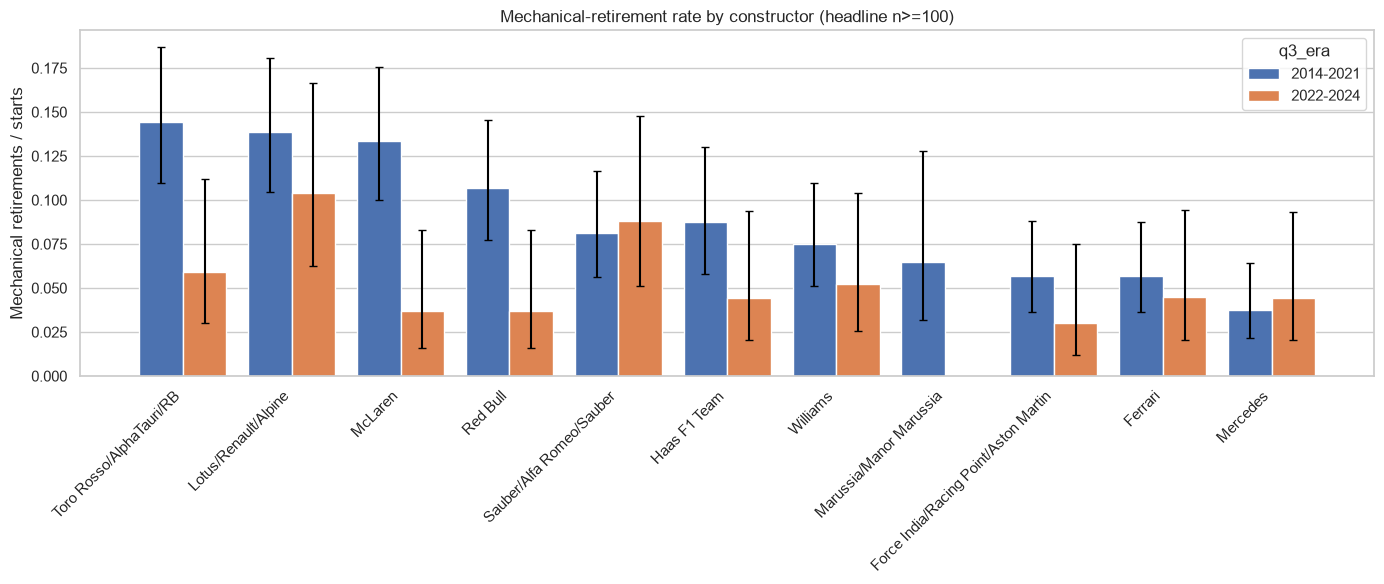

Saved figure: figures_de/q3_mechanical_rate_era_change.png


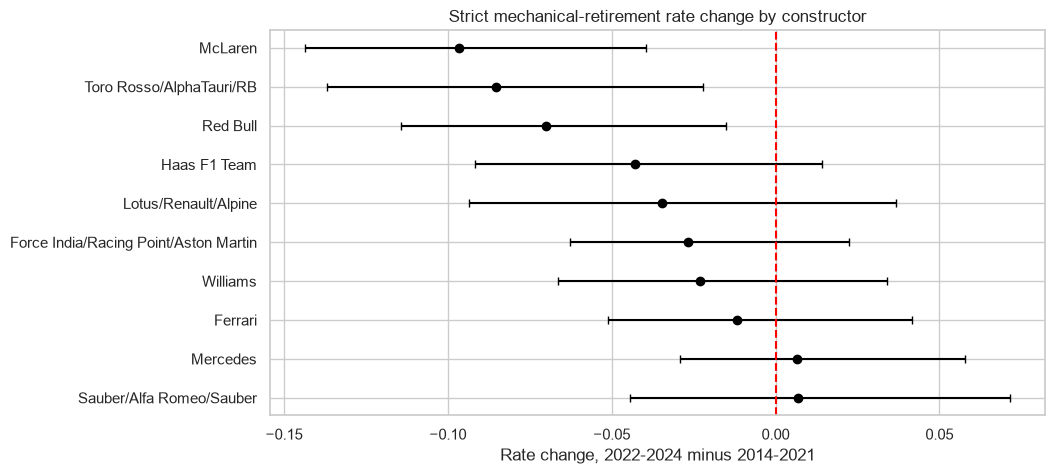

In [ ]:
de_q3_constructor_candidates = de_q3[["constructorId","constructor_name"]].drop_duplicates().sort_values(["constructor_name","constructorId"])
print(f"Q3 constructor candidates in {de_hybrid_start_year}-{de_q3_new_end_year}:"); display(de_q3_constructor_candidates)
de_lineage_by_name = {"Force India":"Force India/Racing Point/Aston Martin","Racing Point":"Force India/Racing Point/Aston Martin","Aston Martin":"Force India/Racing Point/Aston Martin","Toro Rosso":"Toro Rosso/AlphaTauri/RB","AlphaTauri":"Toro Rosso/AlphaTauri/RB","RB F1 Team":"Toro Rosso/AlphaTauri/RB","RB":"Toro Rosso/AlphaTauri/RB","Lotus F1":"Lotus/Renault/Alpine","Renault":"Lotus/Renault/Alpine","Alpine F1 Team":"Lotus/Renault/Alpine","Sauber":"Sauber/Alfa Romeo/Sauber","Alfa Romeo":"Sauber/Alfa Romeo/Sauber","Marussia":"Marussia/Manor Marussia","Manor Marussia":"Marussia/Manor Marussia"}
de_q3_lineage_table = de_q3_constructor_candidates.copy()
de_q3_lineage_table["constructor_lineage"] = de_q3_lineage_table["constructor_name"].map(de_lineage_by_name).fillna(de_q3_lineage_table["constructor_name"])
print("Q3 constructor lineage table:"); display(de_q3_lineage_table)
de_q3["constructor_lineage"] = de_q3["constructor_name"].map(de_lineage_by_name).fillna(de_q3["constructor_name"])
de_q3["constructor_group"] = np.where(de_merge_lineages, de_q3["constructor_lineage"], de_q3["constructor_name"])
print("Q3 de_merge_lineages:", de_merge_lineages)

def de_mechanical_rate_table(de_df, de_category_col, de_constructor_col, de_min_starts=de_min_n):
    de_calc = de_df.copy(); de_calc["is_mechanical"] = de_calc[de_category_col].eq("mechanical")
    de_out = de_calc.groupby(["q3_era",de_constructor_col]).agg(starts=("is_mechanical","size"), mechanical_retirements=("is_mechanical","sum")).reset_index().rename(columns={de_constructor_col:"constructor"})
    de_out["mechanical_rate"] = de_out["mechanical_retirements"] / de_out["starts"]
    de_out = de_add_wilson(de_out, "mechanical_retirements", "starts", "mechanical_rate")
    de_out = de_out.loc[de_out["starts"] >= de_min_starts].copy()
    de_out["rank"] = de_out.groupby("q3_era")["mechanical_rate"].rank(ascending=False, method="min")
    return de_out.sort_values(["q3_era","rank","starts"], ascending=[True,True,False])

def de_era_change_table(de_table, de_mapping):
    de_a = de_table.loc[de_table["q3_era"].eq(de_q3_era_a), ["constructor","starts","mechanical_retirements","mechanical_rate","mechanical_rate_ci_low","mechanical_rate_ci_high"]].rename(columns={"starts":"starts_2014_2021","mechanical_retirements":"mechanical_2014_2021","mechanical_rate":"rate_2014_2021","mechanical_rate_ci_low":"rate_2014_2021_ci_low","mechanical_rate_ci_high":"rate_2014_2021_ci_high"})
    de_b = de_table.loc[de_table["q3_era"].eq(de_q3_era_b), ["constructor","starts","mechanical_retirements","mechanical_rate","mechanical_rate_ci_low","mechanical_rate_ci_high"]].rename(columns={"starts":"starts_2022_2024","mechanical_retirements":"mechanical_2022_2024","mechanical_rate":"rate_2022_2024","mechanical_rate_ci_low":"rate_2022_2024_ci_low","mechanical_rate_ci_high":"rate_2022_2024_ci_high"})
    de_common_constructors = sorted(set(de_a["constructor"]) & set(de_b["constructor"]))
    de_a = de_a.loc[de_a["constructor"].isin(de_common_constructors)].copy()
    de_b = de_b.loc[de_b["constructor"].isin(de_common_constructors)].copy()
    de_out = de_checked_merge(de_a, de_b, on="constructor", how="left", validate="one_to_one", name=f"Q3 {de_mapping} constructor era A -> era B")
    de_out["rate_delta_2022_2024_minus_2014_2021"] = de_out["rate_2022_2024"] - de_out["rate_2014_2021"]
    de_out["rate_delta_ci_low"] = de_out["rate_delta_2022_2024_minus_2014_2021"] - np.sqrt((de_out["rate_2022_2024"] - de_out["rate_2022_2024_ci_low"])**2 + (de_out["rate_2014_2021_ci_high"] - de_out["rate_2014_2021"])**2)
    de_out["rate_delta_ci_high"] = de_out["rate_delta_2022_2024_minus_2014_2021"] + np.sqrt((de_out["rate_2022_2024_ci_high"] - de_out["rate_2022_2024"])**2 + (de_out["rate_2014_2021"] - de_out["rate_2014_2021_ci_low"])**2)
    return de_out.sort_values("rate_delta_2022_2024_minus_2014_2021", ascending=False)

de_q3_era_a = "2014-2021"; de_q3_era_b = "2022-2024"
de_q3_strict_by_name = de_mechanical_rate_table(de_q3, "strict_category", "constructor_name")
de_q3_lenient_by_name = de_mechanical_rate_table(de_q3, "lenient_category", "constructor_name")
de_q3_strict_table_full = de_mechanical_rate_table(de_q3, "strict_category", "constructor_group", de_min_n)
de_q3_lenient_table_full = de_mechanical_rate_table(de_q3, "lenient_category", "constructor_group", de_min_n)
de_q3_strict_table = de_mechanical_rate_table(de_q3, "strict_category", "constructor_group", de_min_n_headline)
de_q3_lenient_table = de_mechanical_rate_table(de_q3, "lenient_category", "constructor_group", de_min_n_headline)
print("Q3 strict by constructor name:", de_q3_strict_by_name.shape); display(de_q3_strict_by_name)
print("Q3 lenient by constructor name:", de_q3_lenient_by_name.shape); display(de_q3_lenient_by_name)
print(f"Q3 strict selected lineage headline table (n>={de_min_n_headline}):", de_q3_strict_table.shape); display(de_q3_strict_table)
print(f"Q3 lenient selected lineage headline table (n>={de_min_n_headline}):", de_q3_lenient_table.shape); display(de_q3_lenient_table)
print(f"Q3 strict selected lineage full table (n>={de_min_n}; small samples included):", de_q3_strict_table_full.shape); display(de_q3_strict_table_full)
print(f"Q3 lenient selected lineage full table (n>={de_min_n}; small samples included):", de_q3_lenient_table_full.shape); display(de_q3_lenient_table_full)

de_q3_rank_change = de_checked_merge(de_q3_strict_table[["q3_era","constructor","rank","mechanical_rate"]].rename(columns={"rank":"strict_rank","mechanical_rate":"strict_rate"}), de_q3_lenient_table[["q3_era","constructor","rank","mechanical_rate"]].rename(columns={"rank":"lenient_rank","mechanical_rate":"lenient_rate"}), on=["q3_era","constructor"], how="left", validate="one_to_one", name="Q3 strict rank -> lenient rank")
de_q3_rank_change["rank_delta_lenient_minus_strict"] = de_q3_rank_change["lenient_rank"] - de_q3_rank_change["strict_rank"]
print("Q3 strict vs lenient rank comparison:"); display(de_q3_rank_change)
de_q3_only_a = sorted(set(de_q3_strict_table.loc[de_q3_strict_table["q3_era"].eq(de_q3_era_a), "constructor"]) - set(de_q3_strict_table.loc[de_q3_strict_table["q3_era"].eq(de_q3_era_b), "constructor"]))
de_q3_only_b = sorted(set(de_q3_strict_table.loc[de_q3_strict_table["q3_era"].eq(de_q3_era_b), "constructor"]) - set(de_q3_strict_table.loc[de_q3_strict_table["q3_era"].eq(de_q3_era_a), "constructor"]))
print(f"Q3 constructors only in {de_q3_era_a}:", de_q3_only_a)
print(f"Q3 constructors only in {de_q3_era_b}:", de_q3_only_b)

de_q3_era_level_strict = de_q3.assign(is_mechanical=de_q3["strict_category"].eq("mechanical")).groupby("q3_era").agg(starts=("is_mechanical","size"), mechanical_retirements=("is_mechanical","sum")).reset_index()
de_q3_era_level_strict["mechanical_rate"] = de_q3_era_level_strict["mechanical_retirements"] / de_q3_era_level_strict["starts"]
de_q3_era_level_strict = de_add_wilson(de_q3_era_level_strict, "mechanical_retirements", "starts", "mechanical_rate")
de_q3_era_level_strict["mapping"] = "strict"
de_q3_era_level_lenient = de_q3.assign(is_mechanical=de_q3["lenient_category"].eq("mechanical")).groupby("q3_era").agg(starts=("is_mechanical","size"), mechanical_retirements=("is_mechanical","sum")).reset_index()
de_q3_era_level_lenient["mechanical_rate"] = de_q3_era_level_lenient["mechanical_retirements"] / de_q3_era_level_lenient["starts"]
de_q3_era_level_lenient = de_add_wilson(de_q3_era_level_lenient, "mechanical_retirements", "starts", "mechanical_rate")
de_q3_era_level_lenient["mapping"] = "lenient"
de_q3_era_level = pd.concat([de_q3_era_level_strict, de_q3_era_level_lenient], ignore_index=True)
de_q3_ztest_rows = []
for de_mapping, de_sub in de_q3_era_level.groupby("mapping"):
    de_sub = de_sub.set_index("q3_era").loc[[de_q3_era_a, de_q3_era_b]]
    de_z, de_p = proportions_ztest(de_sub["mechanical_retirements"].to_numpy(), de_sub["starts"].to_numpy())
    de_cluster = de_q3.copy()
    de_cluster["is_new_era_int"] = de_cluster["q3_era"].eq(de_q3_era_b).astype(int)
    de_cluster["is_mechanical_int"] = de_cluster[f"{de_mapping}_category"].eq("mechanical").astype(int)
    de_cluster_logit = smf.logit("is_mechanical_int ~ is_new_era_int", data=de_cluster).fit(disp=False, maxiter=500, cov_type="cluster", cov_kwds={"groups": de_cluster["raceId"]})
    de_q3_ztest_rows.append({"mapping":de_mapping,"z_stat":float(de_z),"p_value":float(de_p),"cluster_logit_p_value":float(de_cluster_logit.pvalues["is_new_era_int"]),"rate_delta_2022_2024_minus_2014_2021":float(de_sub.loc[de_q3_era_b,"mechanical_rate"] - de_sub.loc[de_q3_era_a,"mechanical_rate"])})
de_q3_ztest_table = pd.DataFrame(de_q3_ztest_rows)
print("Q3 era-level mechanical-retirement rates:"); display(de_q3_era_level)
print("Q3 era-level two-proportion z-tests:"); display(de_q3_ztest_table)

de_q3_strict_era_change = de_era_change_table(de_q3_strict_table_full, "strict")
de_q3_lenient_era_change = de_era_change_table(de_q3_lenient_table_full, "lenient")
print(f"Q3 strict per-constructor era change (full n>={de_min_n} table):"); display(de_q3_strict_era_change)
print(f"Q3 lenient per-constructor era change (full n>={de_min_n} table):"); display(de_q3_lenient_era_change)

de_q3_small_sample_strict = de_q3_strict_table_full.loc[de_q3_strict_table_full["starts"].lt(de_min_n_headline)].sort_values("mechanical_rate", ascending=False)
de_q3_highest_small_sample = de_q3_small_sample_strict.head(1)
de_q3_caterham_rows = de_q3_strict_table_full.loc[de_q3_strict_table_full["constructor"].eq("Caterham")]
if not de_q3_caterham_rows.empty:
    de_q3_caterham_example = de_q3_caterham_rows.sort_values("mechanical_rate", ascending=False).iloc[0]
    print(f"Q3 headline exclusion note: constructors with <{de_min_n_headline} starts, e.g. {de_q3_caterham_example['constructor']} ({int(de_q3_caterham_example['mechanical_retirements'])}/{int(de_q3_caterham_example['starts'])} in {de_q3_caterham_example['q3_era']}), are excluded from the headline.")
if not de_q3_highest_small_sample.empty:
    de_q3_small = de_q3_highest_small_sample.iloc[0]
    print(f"Q3 highest-rate small-sample constructor in the n>={de_min_n} strict table: {de_q3_small['constructor']} in {de_q3_small['q3_era']} at {de_q3_small['mechanical_rate']:.1%} ({int(de_q3_small['mechanical_retirements'])}/{int(de_q3_small['starts'])}).")

de_q3_order = de_q3_strict_table.groupby("constructor")["mechanical_rate"].max().sort_values(ascending=False).index.tolist()
de_fig, de_ax = de_grouped_bar_ci(de_q3_strict_table, "constructor", "mechanical_rate", "mechanical_rate_ci_low", "mechanical_rate_ci_high", "q3_era", de_q3_order, [de_q3_era_a,de_q3_era_b], f"Mechanical-retirement rate by constructor (headline n>={de_min_n_headline})", "Mechanical retirements / starts", 45, (14,6))
de_save_show(de_fig, "q3_mechanical_rate_constructor.png")

de_q3_change_plot = de_q3_strict_era_change.copy()
de_fig, de_ax = plt.subplots(figsize=(10,5))
de_ax.errorbar(de_q3_change_plot["rate_delta_2022_2024_minus_2014_2021"], de_q3_change_plot["constructor"], xerr=[de_q3_change_plot["rate_delta_2022_2024_minus_2014_2021"]-de_q3_change_plot["rate_delta_ci_low"], de_q3_change_plot["rate_delta_ci_high"]-de_q3_change_plot["rate_delta_2022_2024_minus_2014_2021"]], fmt="o", color="black", capsize=3)
de_ax.axvline(0, color="red", linestyle="--"); de_ax.set_title("Strict mechanical-retirement rate change by constructor"); de_ax.set_xlabel(f"Rate change, {de_q3_era_b} minus {de_q3_era_a}")
de_save_show(de_fig, "q3_mechanical_rate_era_change.png")


## Q3 note on grain, missingness, and pre-race cutoff

The denominator is all cleaned starts in each constructor-era group. Status is post-race and is used only to retrospectively classify retirement causes, never as a prediction feature. Ambiguous statuses are separated by strict versus lenient mappings; lineage merging is controlled by `de_merge_lineages`.

In [ ]:
de_q3_top5 = de_q3_strict_table.sort_values(["q3_era","rank","starts"], ascending=[True,True,False]).groupby("q3_era").head(5).copy()
print(f"Q3 top 5 constructors per era, strict selected lineage headline table (n>={de_min_n_headline}):")
display(de_q3_top5)
de_q3_best_2014 = de_q3_strict_table.loc[de_q3_strict_table["q3_era"].eq(de_q3_era_a)].head(1)
de_q3_best_2022 = de_q3_strict_table.loc[de_q3_strict_table["q3_era"].eq(de_q3_era_b)].head(1)
de_q3_lenient_best_2014 = de_q3_lenient_table.loc[de_q3_lenient_table["q3_era"].eq(de_q3_era_a)].head(1)
de_q3_lenient_best_2022 = de_q3_lenient_table.loc[de_q3_lenient_table["q3_era"].eq(de_q3_era_b)].head(1)
de_q3_top_changes = (de_q3_best_2014.iloc[0]["constructor"] != de_q3_lenient_best_2014.iloc[0]["constructor"]) or (de_q3_best_2022.iloc[0]["constructor"] != de_q3_lenient_best_2022.iloc[0]["constructor"])

def de_q3_era_rate_text(de_mapping):
    de_rates = de_q3_era_level.loc[de_q3_era_level["mapping"].eq(de_mapping)].set_index("q3_era")
    de_test = de_q3_ztest_table.loc[de_q3_ztest_table["mapping"].eq(de_mapping)].iloc[0]
    return (f"{de_mapping}: {de_q3_era_a} {de_rates.loc[de_q3_era_a,'mechanical_rate']:.1%} "
            f"({int(de_rates.loc[de_q3_era_a,'mechanical_retirements'])}/{int(de_rates.loc[de_q3_era_a,'starts'])}) vs "
            f"{de_q3_era_b} {de_rates.loc[de_q3_era_b,'mechanical_rate']:.1%} "
            f"({int(de_rates.loc[de_q3_era_b,'mechanical_retirements'])}/{int(de_rates.loc[de_q3_era_b,'starts'])}), "
            f"naive z-test p={de_test['p_value']:.3g}, race-clustered logit p={de_test['cluster_logit_p_value']:.3g}")

de_q3_significant_strict_change = de_q3_strict_era_change.loc[de_q3_strict_era_change["rate_delta_ci_high"].lt(0) | de_q3_strict_era_change["rate_delta_ci_low"].gt(0)].copy()
if de_q3_significant_strict_change.empty:
    de_q3_significant_change_text = "No constructor's strict per-constructor delta CI excludes zero"
else:
    de_q3_significant_change_text = "; ".join(f"{de_row.constructor}: {de_row.rate_delta_2022_2024_minus_2014_2021*100:+.1f} pp" for de_row in de_q3_significant_strict_change.itertuples())
de_q3_remaining_constructor_count = int(len(de_q3_strict_era_change) - len(de_q3_significant_strict_change))
de_q3_status_judgment_counts = de_q3.loc[de_q3["status"].isin(["Front wing","Rear wing","Seat","Wheel"]), "status"].value_counts().sort_index()
de_q3_status_judgment_text = ", ".join(f"{de_status}: {int(de_count)}" for de_status, de_count in de_q3_status_judgment_counts.items())
de_q3_answer = (
    f"Q3 answer: Mechanical-retirement rates use starts as the denominator, Wilson intervals for uncertainty, and the headline tables require at least {de_min_n_headline} starts. "
    + f"In {de_q3_era_a}, the highest strict headline rate is {de_q3_best_2014.iloc[0]['constructor']} at {de_q3_best_2014.iloc[0]['mechanical_rate']:.1%} ({int(de_q3_best_2014.iloc[0]['mechanical_retirements'])}/{int(de_q3_best_2014.iloc[0]['starts'])}); the highest lenient rate is {de_q3_lenient_best_2014.iloc[0]['constructor']} at {de_q3_lenient_best_2014.iloc[0]['mechanical_rate']:.1%} ({int(de_q3_lenient_best_2014.iloc[0]['mechanical_retirements'])}/{int(de_q3_lenient_best_2014.iloc[0]['starts'])}). "
    + f"In {de_q3_era_b}, the highest strict headline rate is {de_q3_best_2022.iloc[0]['constructor']} at {de_q3_best_2022.iloc[0]['mechanical_rate']:.1%} ({int(de_q3_best_2022.iloc[0]['mechanical_retirements'])}/{int(de_q3_best_2022.iloc[0]['starts'])}); the highest lenient rate is {de_q3_lenient_best_2022.iloc[0]['constructor']} at {de_q3_lenient_best_2022.iloc[0]['mechanical_rate']:.1%} ({int(de_q3_lenient_best_2022.iloc[0]['mechanical_retirements'])}/{int(de_q3_lenient_best_2022.iloc[0]['starts'])}). "
    + f"League-wide era rates are {de_q3_era_rate_text('strict')}; {de_q3_era_rate_text('lenient')}. "
    + f"Strict per-constructor delta CIs excluding zero: {de_q3_significant_change_text}. The remaining {de_q3_remaining_constructor_count} constructors show no significant change. "
    + f"The top constructor changes between strict and lenient mappings: {de_q3_top_changes}. Status judgment-call counts are {de_q3_status_judgment_text}. "
    + f"Limitations: starts are treated as independent, two cars at one race share conditions, status labels are coarse, {de_q3_era_b} has only {de_q3_new_end_year - de_q3_new_start_year + 1} seasons, no multiple-comparisons adjustment is applied across constructors so some significant deltas are expected by chance, mechanical failures may reflect the engine supplier rather than the named constructor, and lineage merging changes the interpretation."
)
print(de_q3_answer)


Q3 top 5 constructors per era, strict selected lineage headline table (n>=100):


,q3_era,constructor,starts,mechanical_retirements,mechanical_rate,mechanical_rate_ci_low,mechanical_rate_ci_high,rank
10,2014-2021,Toro Rosso/AlphaTauri/RB,319,46,0.144201,0.109881,0.186987,1.0
4,2014-2021,Lotus/Renault/Alpine,318,44,0.138365,0.104712,0.180650,2.0
6,2014-2021,McLaren,315,42,0.133333,0.100178,0.175324,3.0
8,2014-2021,Red Bull,318,34,0.106918,0.077526,0.145694,4.0
3,2014-2021,Haas F1 Team,240,21,0.087500,0.057942,0.130055,5.0
15,2022-2024,Lotus/Renault/Alpine,135,14,0.103704,0.062785,0.166552,1.0
19,2022-2024,Sauber/Alfa Romeo/Sauber,136,12,0.088235,0.051195,0.147898,2.0
20,2022-2024,Toro Rosso/AlphaTauri/RB,136,8,0.058824,0.030105,0.111780,3.0
21,2022-2024,Williams,134,7,0.052239,0.025532,0.103903,4.0
12,2022-2024,Ferrari,134,6,0.044776,0.020680,0.094245,5.0


Q3 answer: Mechanical-retirement rates use starts as the denominator, Wilson intervals for uncertainty, and the headline tables require at least 100 starts. In 2014-2021, the highest strict headline rate is Toro Rosso/AlphaTauri/RB at 14.4% (46/319); the highest lenient rate is Toro Rosso/AlphaTauri/RB at 16.3% (52/319). In 2022-2024, the highest strict headline rate is Lotus/Renault/Alpine at 10.4% (14/135); the highest lenient rate is Lotus/Renault/Alpine at 10.4% (14/135). League-wide era rates are strict: 2014-2021 9.2% (299/3244) vs 2022-2024 5.4% (73/1351), naive z-test p=1.58e-05, race-clustered logit p=0.000147; lenient: 2014-2021 10.9% (354/3244) vs 2022-2024 6.7% (90/1351), naive z-test p=8.86e-06, race-clustered logit p=3.59e-05. Strict per-constructor delta CIs excluding zero: Red Bull: -7.0 pp; Toro Rosso/AlphaTauri/RB: -8.5 pp; McLaren: -9.7 pp. The remaining 7 constructors show no significant change. The top constructor changes between strict and lenient mappings: False.

## Q3 written answer

The headline constructor tables use at least `de_min_n_headline = 100` starts, while the full `n>=10` tables remain displayed with a small-sample warning. Strict mechanical retirements include explicit component failures; lenient mechanical retirements additionally include ambiguous labels such as retired, puncture, tyre, undertray, wheel nut, vibrations, damage, and debris. The final status mapping table documents every observed 2014-2024 status, and the notebook asserts if any status is left `UNREVIEWED`.

The era-level table and z-tests compare the league-wide mechanical-retirement rate in 2014-2021 against 2022-2024 under both strict and lenient mappings. `de_q3_ztest_table` reports both the naive two-proportion z-test and the race-clustered logit p-value. The per-constructor era-change tables show `rate_2022-2024 - rate_2014-2021` for constructors present in both eras, with approximate confidence intervals and a strict-mapping change plot. The printed answer lists the constructors whose strict delta confidence interval excludes zero and states that the remaining constructors show no significant change.

Grain: one cleaned `results` row per `(raceId, driverId)` start in 2014-2024. Missingness: `statusId` has no nulls by assertion, every observed status maps to a reviewed category, and no unmapped statuses remain. Pre-race cutoff: Q3 is retrospective by design because retirement cause is only known after the race. Caveats: starts are treated as independent, but two cars at one race share conditions, so the p-values and CIs are somewhat optimistic; wing and seat statuses are classified as accident/driver, while Wheel is classified as mechanical and Out of fuel is ambiguous (mechanical only in the lenient mapping), and these are judgment calls with counts reported in `de_q3_answer`; Disqualified/Excluded rows stay in the denominator because those drivers finished the race. Limitations: status labels are coarse, no multiple-comparisons adjustment is applied across constructors so some significant deltas are expected by chance, mechanical failures may belong to an engine supplier rather than the named constructor, customer teams complicate attribution, 2022-2024 has only three seasons, and lineage merging changes the unit being ranked.


In [ ]:
# Added for G2: verify the loaded tables were not mutated by the analysis.
de_table_hash_current = {de_name: de_table_hash(de_table) for de_name, de_table in tables.items()}
de_table_hash_changed = {de_name: (de_table_hash_snapshot[de_name], de_table_hash_current[de_name]) for de_name in de_table_names if de_table_hash_snapshot[de_name] != de_table_hash_current[de_name]}
print("Tables changed since load:", de_table_hash_changed)
assert not de_table_hash_changed, "tables was mutated after the initial hash snapshot"


Tables changed since load: {}
